In [1]:
import requests

github_api = "https://api.github.com/repos/Smithsonian/openaccess/contents"

response = requests.get(github_api)

print(response.status_code)

200


In [2]:
import boto3
import json
import pandas as pd
from botocore import UNSIGNED
from botocore.client import Config

# ============================================================
# SMITHSONIAN OPEN ACCESS
# Public AWS S3 bucket — no AWS account required
# ============================================================

BUCKET = "smithsonian-open-access"

s3 = boto3.client(
    "s3",
    region_name="us-west-2",
    config=Config(signature_version=UNSIGNED)
)

print("Connected to Smithsonian Open Access")
print("Bucket:", BUCKET)

# Get the first 20 objects in the public bucket
response = s3.list_objects_v2(
    Bucket=BUCKET,
    MaxKeys=20
)

print("\nFiles found:")

for obj in response.get("Contents", []):
    print(obj["Key"])

Connected to Smithsonian Open Access
Bucket: smithsonian-open-access

Files found:
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-1024-low-nondraco.glb
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-1024-low.bin
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-1024-low.glb
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-1024-low.gltf
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-1024-normals.jpg
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-1024-occlusion.jpg
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-2048-medium-nondraco.glb
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-2048-medium.bin
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-2048-medium.glb
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-150k-2048-medium.gltf
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cran

In [3]:
# Find Smithsonian metadata files instead of 3D assets

response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix="",
    MaxKeys=1000
)

metadata_files = []

for obj in response.get("Contents", []):
    key = obj["Key"].lower()

    if (
        key.endswith(".json")
        or key.endswith(".jsonl")
        or "metadata" in key
    ):
        metadata_files.append(obj["Key"])

print("Metadata candidates found:", len(metadata_files))

for key in metadata_files[:50]:
    print(key)

Metadata candidates found: 264
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/USNM153798_cranium_-400-20k-512-remesh-thumb-multi-report.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_PxBNCzKY7fFT.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_dQeV33VSaHPI.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_gf740cmNIjpP.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_mGuc1RdGlfIM.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_oecLs0uGNkvz.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_qcu1abiD9C04.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_ub446VvZX3Tw.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_uviYChu4f5o5.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_wmAx7WgPssDW.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_meshsmith_zIvhdOFTBfnk.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/_rapidcompact_V8lTRVZU7VFT.json
3d/002f2567-7384-4027-9b99-bcb7a7e6361e/scene.svx.json
3d/00416a1c-358a-4f5b-9a90-053df0d6fd31/USNM14217

In [4]:
# ============================================================
# FIND SMITHSONIAN COLLECTION METADATA
# ============================================================

import boto3
from botocore import UNSIGNED
from botocore.client import Config

BUCKET = "smithsonian-open-access"

s3 = boto3.client(
    "s3",
    region_name="us-west-2",
    config=Config(signature_version=UNSIGNED)
)

# Search deeper through the bucket
paginator = s3.get_paginator("list_objects_v2")

metadata_candidates = []

for page in paginator.paginate(Bucket=BUCKET):

    for obj in page.get("Contents", []):

        key = obj["Key"]

        # We want collection/data files,
        # NOT 3D processing files.
        key_lower = key.lower()

        if (
            (key_lower.endswith(".json") or
             key_lower.endswith(".jsonl"))
            and
            "3d/" not in key_lower
            and
            "_meshsmith" not in key_lower
            and
            "scene." not in key_lower
        ):
            metadata_candidates.append(
                {
                    "key": key,
                    "size_mb": round(
                        obj["Size"] / (1024 * 1024), 2
                    )
                }
            )

        # Stop after finding enough candidates
        if len(metadata_candidates) >= 100:
            break

    if len(metadata_candidates) >= 100:
        break


print("=" * 70)
print("SMITHSONIAN COLLECTION METADATA CANDIDATES")
print("=" * 70)

print(
    "Candidates found:",
    len(metadata_candidates)
)

for item in metadata_candidates[:100]:

    print(
        f"{item['size_mb']:>8} MB   "
        f"{item['key']}"
    )

KeyboardInterrupt: 

In [5]:
# Check the top-level Smithsonian bucket structure only

response = s3.list_objects_v2(
    Bucket="smithsonian-open-access",
    Delimiter="/"
)

print("TOP-LEVEL FOLDERS")
print("=" * 50)

for prefix in response.get("CommonPrefixes", []):
    print(prefix["Prefix"])

TOP-LEVEL FOLDERS
3d/
images/
media/
metadata/


In [6]:
# ============================================================
# INSPECT SMITHSONIAN METADATA FOLDER
# ============================================================

response = s3.list_objects_v2(
    Bucket="smithsonian-open-access",
    Prefix="metadata/",
    Delimiter="/"
)

print("METADATA SUBFOLDERS")
print("=" * 60)

for prefix in response.get("CommonPrefixes", []):
    print(prefix["Prefix"])

print("\nDIRECT FILES")
print("=" * 60)

for obj in response.get("Contents", [])[:50]:
    print(obj["Key"])

METADATA SUBFOLDERS
metadata/edan/

DIRECT FILES


In [7]:
# ============================================================
# INSPECT EDAN METADATA
# ============================================================

response = s3.list_objects_v2(
    Bucket="smithsonian-open-access",
    Prefix="metadata/edan/",
    Delimiter="/"
)

print("EDAN SUBFOLDERS")
print("=" * 60)

for prefix in response.get("CommonPrefixes", []):
    print(prefix["Prefix"])

print("\nDIRECT FILES")
print("=" * 60)

for obj in response.get("Contents", [])[:50]:
    print(obj["Key"])

EDAN SUBFOLDERS
metadata/edan/aaa/
metadata/edan/aag/
metadata/edan/acah/
metadata/edan/acm/
metadata/edan/acma/
metadata/edan/cfchfolklife/
metadata/edan/chndm/
metadata/edan/chsdm/
metadata/edan/eepa/
metadata/edan/fbr/
metadata/edan/fs/
metadata/edan/fsa/
metadata/edan/fsg/
metadata/edan/hac/
metadata/edan/hmsg/
metadata/edan/hsfa/
metadata/edan/naa/
metadata/edan/nasm/
metadata/edan/nasmac/
metadata/edan/nmaa/
metadata/edan/nmaahc/
metadata/edan/nmafa/
metadata/edan/nmah/
metadata/edan/nmai/
metadata/edan/nmaia/
metadata/edan/nmnhanthro/
metadata/edan/nmnhbirds/
metadata/edan/nmnhbotany/
metadata/edan/nmnheducation/
metadata/edan/nmnhento/
metadata/edan/nmnhfishes/
metadata/edan/nmnhherps/
metadata/edan/nmnhinv/
metadata/edan/nmnhmammals/
metadata/edan/nmnhminsci/
metadata/edan/nmnhpaleo/
metadata/edan/npg/
metadata/edan/npgcap/
metadata/edan/npm/
metadata/edan/npma/
metadata/edan/nzp/
metadata/edan/ocio_dpo3d/
metadata/edan/ofeo-sg/
metadata/edan/saam/
metadata/edan/saampaik/
meta

In [8]:
# ============================================================
# SMITHSONIAN — NATIONAL MUSEUM OF AMERICAN HISTORY
# Inspect available metadata files
# ============================================================

response = s3.list_objects_v2(
    Bucket="smithsonian-open-access",
    Prefix="metadata/edan/nmah/",
    Delimiter="/"
)

print("NMAH SUBFOLDERS")
print("=" * 60)

for prefix in response.get("CommonPrefixes", []):
    print(prefix["Prefix"])

print("\nNMAH FILES")
print("=" * 60)

for obj in response.get("Contents", [])[:50]:
    print(
        obj["Key"],
        "|",
        round(obj["Size"] / (1024 * 1024), 2),
        "MB"
    )

NMAH SUBFOLDERS

NMAH FILES
metadata/edan/nmah/00.txt | 9.3 MB
metadata/edan/nmah/01.txt | 9.35 MB
metadata/edan/nmah/02.txt | 9.27 MB
metadata/edan/nmah/03.txt | 9.12 MB
metadata/edan/nmah/04.txt | 9.41 MB
metadata/edan/nmah/05.txt | 9.44 MB
metadata/edan/nmah/06.txt | 9.43 MB
metadata/edan/nmah/07.txt | 9.19 MB
metadata/edan/nmah/08.txt | 9.3 MB
metadata/edan/nmah/09.txt | 9.18 MB
metadata/edan/nmah/0a.txt | 9.08 MB
metadata/edan/nmah/0b.txt | 9.31 MB
metadata/edan/nmah/0c.txt | 9.31 MB
metadata/edan/nmah/0d.txt | 9.38 MB
metadata/edan/nmah/0e.txt | 9.35 MB
metadata/edan/nmah/0f.txt | 9.25 MB
metadata/edan/nmah/10.txt | 9.35 MB
metadata/edan/nmah/11.txt | 9.35 MB
metadata/edan/nmah/12.txt | 9.13 MB
metadata/edan/nmah/13.txt | 9.59 MB
metadata/edan/nmah/14.txt | 9.38 MB
metadata/edan/nmah/15.txt | 9.18 MB
metadata/edan/nmah/16.txt | 9.42 MB
metadata/edan/nmah/17.txt | 9.27 MB
metadata/edan/nmah/18.txt | 9.41 MB
metadata/edan/nmah/19.txt | 9.31 MB
metadata/edan/nmah/1a.txt | 9.42 MB
me

In [9]:
# ============================================================
# HERITAGE INTELLIGENCE
# SMITHSONIAN NMAH INGESTION
# ============================================================

import boto3
import json
import pandas as pd
from botocore import UNSIGNED
from botocore.client import Config
from io import BytesIO

BUCKET = "smithsonian-open-access"
PREFIX = "metadata/edan/nmah/"

s3 = boto3.client(
    "s3",
    region_name="us-west-2",
    config=Config(signature_version=UNSIGNED)
)

print("=" * 70)
print("SMITHSONIAN NMAH DATA INGESTION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Find available NMAH files
# ------------------------------------------------------------

response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix=PREFIX
)

files = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".txt")
]

files = sorted(files)

print(f"\nAvailable NMAH shards: {len(files)}")


# ------------------------------------------------------------
# 2. Select representative shards
# ------------------------------------------------------------

# We deliberately DON'T download everything.
# We sample across the collection.

if len(files) >= 10:

    selected_files = [
        files[0],
        files[len(files)//4],
        files[len(files)//2],
        files[(3 * len(files))//4],
        files[-1]
    ]

else:

    selected_files = files


print("\nSelected shards:")

for file in selected_files:
    print(" ", file)


# ------------------------------------------------------------
# 3. Download and parse records
# ------------------------------------------------------------

records = []

MAX_RECORDS = 15000

for file in selected_files:

    print(f"\nDownloading: {file}")

    obj = s3.get_object(
        Bucket=BUCKET,
        Key=file
    )

    raw_data = obj["Body"].read()

    print(
        "Downloaded:",
        round(len(raw_data) / (1024 * 1024), 2),
        "MB"
    )

    text = raw_data.decode(
        "utf-8",
        errors="ignore"
    )

    lines = text.splitlines()

    print(
        "Lines:",
        f"{len(lines):,}"
    )

    for line in lines:

        line = line.strip()

        if not line:
            continue

        try:

            record = json.loads(line)

            if isinstance(record, dict):

                records.append(record)

        except json.JSONDecodeError:

            continue

        if len(records) >= MAX_RECORDS:
            break

    if len(records) >= MAX_RECORDS:
        break


# ------------------------------------------------------------
# 4. Create dataframe
# ------------------------------------------------------------

print("\nCreating Pandas dataframe...")

smithsonian_df = pd.json_normalize(
    records
)

print(
    f"Smithsonian records loaded: "
    f"{len(smithsonian_df):,}"
)

print(
    f"Smithsonian fields detected: "
    f"{len(smithsonian_df.columns):,}"
)


# ------------------------------------------------------------
# 5. Add source identifier
# ------------------------------------------------------------

smithsonian_df["museum"] = (
    "Smithsonian National Museum of American History"
)


# ------------------------------------------------------------
# 6. Basic inspection
# ------------------------------------------------------------

print("\nFirst 5 records:")

display(
    smithsonian_df.head()
)


print("\nAvailable fields:")

for column in smithsonian_df.columns:

    print(column)


# ------------------------------------------------------------
# 7. Save raw processed sample
# ------------------------------------------------------------

output_path = (
    "../data/processed/"
    "smithsonian_nmah_sample.csv"
)

smithsonian_df.to_csv(
    output_path,
    index=False
)

print(
    "\nSaved:",
    output_path
)


# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SMITHSONIAN INGESTION COMPLETE")
print("=" * 70)

print(
    f"Records: {len(smithsonian_df):,}"
)

print(
    f"Fields: {len(smithsonian_df.columns):,}"
)

SMITHSONIAN NMAH DATA INGESTION

Available NMAH shards: 257

Selected shards:
  metadata/edan/nmah/00.txt
  metadata/edan/nmah/40.txt
  metadata/edan/nmah/80.txt
  metadata/edan/nmah/c0.txt
  metadata/edan/nmah/index.txt

Downloading: metadata/edan/nmah/00.txt
Downloaded: 9.3 MB
Lines: 5,168

Downloading: metadata/edan/nmah/40.txt
Downloaded: 9.4 MB
Lines: 5,183

Downloading: metadata/edan/nmah/80.txt
Downloaded: 9.46 MB
Lines: 5,232

Creating Pandas dataframe...
Smithsonian records loaded: 15,000
Smithsonian fields detected: 48

First 5 records:


,id,version,unitCode,linkedId,type,url,hash,docSignature,timestamp,lastTimeUpdated,...,content.indexedStructured.culture,content.indexedStructured.exhibition,content.indexedStructured.onPhysicalExhibit,content.freetext.title,content.descriptiveNonRepeating.online_media.media,content.descriptiveNonRepeating.online_media.mediaCount,content.indexedStructured.tax_class,content.indexedStructured.tax_phylum,content.indexedStructured.tax_kingdom,museum
0,ld1-1643399289151-1643399326228-1,,NMAH,,edanmdm,edanmdm:nmah_1699946,00906e8e7ad0d51a1c785b5bb848cf4fdbb08b28,d8273a746984ad4ba707073d945ca444,1663785157,1733310367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smithsonian National Museum of American History
1,ld1-1643399349130-1643399395594-0,,NMAH,,edanmdm,edanmdm:nmah_1602344,00e3512761575e5524b48ca9cf5d9df0317f997b,b299c189c2b8fbeba4d7337194a24f41,1663785868,1733311140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smithsonian National Museum of American History
2,ld1-1643398853934-1643398883789-0,,NMAH,,edanmdm,edanmdm:nmah_1191720,00535ddca9ff10500d744b348f5465d609eb0b87,e2c048dc19aaa63245760bc1bd0a338a,1663782461,1733309374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smithsonian National Museum of American History
3,ld1-1643398853934-1643398894258-0,,NMAH,,edanmdm,edanmdm:nmah_1439698,004ddd3eaf652923ac1d13bad9a1b8a733ed74a5,f73b3e80d85bc52dc9562c062408dfa6,1663782495,1733309374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smithsonian National Museum of American History
4,ld1-1643399349130-1643399355834-0,,NMAH,,edanmdm,edanmdm:nmah_1526828,00370d073cc28e08d4b7824ef1bb9c6605deae0a,d3f0eaf4a9621abdfb05708181943364,1663785868,1733311140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smithsonian National Museum of American History



Available fields:
id
version
unitCode
linkedId
type
url
hash
docSignature
timestamp
lastTimeUpdated
title
content.freetext.name
content.freetext.notes
content.freetext.setName
content.freetext.dataSource
content.freetext.identifier
content.freetext.objectType
content.indexedStructured.name
content.indexedStructured.object_type
content.indexedStructured.online_media_type
content.descriptiveNonRepeating.guid
content.descriptiveNonRepeating.title.label
content.descriptiveNonRepeating.title.content
content.descriptiveNonRepeating.record_ID
content.descriptiveNonRepeating.unit_code
content.descriptiveNonRepeating.title_sort
content.descriptiveNonRepeating.data_source
content.descriptiveNonRepeating.metadata_usage.access
content.indexedStructured.topic
content.freetext.date
content.freetext.place
content.freetext.creditLine
content.freetext.physicalDescription
content.indexedStructured.date
content.indexedStructured.place
content.indexedStructured.geoLocation
content.freetext.topic
content.

In [10]:
print("SMITHSONIAN FIELDS")
print("=" * 70)

for i, column in enumerate(smithsonian_df.columns, 1):
    print(f"{i:02d}. {column}")

SMITHSONIAN FIELDS
01. id
02. version
03. unitCode
04. linkedId
05. type
06. url
07. hash
08. docSignature
09. timestamp
10. lastTimeUpdated
11. title
12. content.freetext.name
13. content.freetext.notes
14. content.freetext.setName
15. content.freetext.dataSource
16. content.freetext.identifier
17. content.freetext.objectType
18. content.indexedStructured.name
19. content.indexedStructured.object_type
20. content.indexedStructured.online_media_type
21. content.descriptiveNonRepeating.guid
22. content.descriptiveNonRepeating.title.label
23. content.descriptiveNonRepeating.title.content
24. content.descriptiveNonRepeating.record_ID
25. content.descriptiveNonRepeating.unit_code
26. content.descriptiveNonRepeating.title_sort
27. content.descriptiveNonRepeating.data_source
28. content.descriptiveNonRepeating.metadata_usage.access
29. content.indexedStructured.topic
30. content.freetext.date
31. content.freetext.place
32. content.freetext.creditLine
33. content.freetext.physicalDescription


In [11]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 4 — UNIVERSAL HERITAGE SCHEMA
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("BUILDING UNIVERSAL HERITAGE DATA MODEL")
print("=" * 70)


# ============================================================
# 1. HELPER — FIND A COLUMN
# ============================================================

def find_column(df, keywords):
    """
    Find the first column whose name contains
    one of the supplied keywords.
    """

    columns = list(df.columns)

    # Exact match first
    for keyword in keywords:

        for column in columns:

            if column.lower() == keyword.lower():
                return column

    # Partial match second
    for keyword in keywords:

        keyword = keyword.lower()

        for column in columns:

            if keyword in column.lower():
                return column

    return None


# ============================================================
# 2. INSPECT POSSIBLE SEMANTIC FIELDS
# ============================================================

print("\nSEARCHING SMITHSONIAN SCHEMA")
print("-" * 70)

search_groups = {

    "ID": [
        "id",
        "identifier",
        "guid"
    ],

    "TITLE": [
        "title"
    ],

    "OBJECT_TYPE": [
        "objecttype",
        "object_type",
        "type"
    ],

    "CREATOR": [
        "name",
        "artist",
        "creator",
        "maker"
    ],

    "CULTURE": [
        "culture",
        "ethnic"
    ],

    "DATE": [
        "date",
        "year",
        "period"
    ],

    "PLACE": [
        "place",
        "country",
        "region",
        "city"
    ],

    "MEDIUM": [
        "medium",
        "material",
        "technique"
    ],

    "IMAGE": [
        "online_media",
        "image",
        "media"
    ],

    "RIGHTS": [
        "rights",
        "access",
        "usage"
    ]
}


for category, keywords in search_groups.items():

    found = find_column(
        smithsonian_df,
        keywords
    )

    print(
        f"{category:15} → {found}"
    )


# ============================================================
# 3. UNIVERSAL DATAFRAME
# ============================================================

heritage_smithsonian = pd.DataFrame()


# ------------------------------------------------------------
# Museum
# ------------------------------------------------------------

heritage_smithsonian["museum"] = (
    "Smithsonian National Museum of American History"
)


# ------------------------------------------------------------
# Object ID
# ------------------------------------------------------------

id_col = find_column(
    smithsonian_df,
    ["id", "identifier", "guid"]
)

if id_col:

    heritage_smithsonian["object_id"] = (
        smithsonian_df[id_col]
    )

else:

    heritage_smithsonian["object_id"] = np.nan


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

title_col = find_column(
    smithsonian_df,
    [
        "content.descriptiveNonRepeating.title.content",
        "content.descriptiveNonRepeating.title.label",
        "title"
    ]
)

if title_col:

    heritage_smithsonian["title"] = (
        smithsonian_df[title_col]
    )

else:

    heritage_smithsonian["title"] = np.nan


# ------------------------------------------------------------
# Object type
# ------------------------------------------------------------

object_type_col = find_column(
    smithsonian_df,
    [
        "content.freetext.objectType",
        "content.indexedStructured.object_type",
        "object_type",
        "objecttype"
    ]
)

if object_type_col:

    heritage_smithsonian["object_type"] = (
        smithsonian_df[object_type_col]
    )

else:

    heritage_smithsonian["object_type"] = np.nan


# ------------------------------------------------------------
# Creator / artist
# ------------------------------------------------------------

creator_col = find_column(
    smithsonian_df,
    [
        "content.freetext.name",
        "content.indexedStructured.name",
        "artist",
        "creator",
        "maker"
    ]
)

if creator_col:

    heritage_smithsonian["artist"] = (
        smithsonian_df[creator_col]
    )

else:

    heritage_smithsonian["artist"] = np.nan


# ------------------------------------------------------------
# Culture
# ------------------------------------------------------------

culture_col = find_column(
    smithsonian_df,
    [
        "culture",
        "ethnic"
    ]
)

if culture_col:

    heritage_smithsonian["culture"] = (
        smithsonian_df[culture_col]
    )

else:

    heritage_smithsonian["culture"] = np.nan


# ------------------------------------------------------------
# Country / place
# ------------------------------------------------------------

country_col = find_column(
    smithsonian_df,
    [
        "country",
        "place",
        "region"
    ]
)

if country_col:

    heritage_smithsonian["country"] = (
        smithsonian_df[country_col]
    )

else:

    heritage_smithsonian["country"] = np.nan


# ------------------------------------------------------------
# Medium / material
# ------------------------------------------------------------

medium_col = find_column(
    smithsonian_df,
    [
        "medium",
        "material",
        "technique"
    ]
)

if medium_col:

    heritage_smithsonian["medium"] = (
        smithsonian_df[medium_col]
    )

else:

    heritage_smithsonian["medium"] = np.nan


# ------------------------------------------------------------
# Classification
# ------------------------------------------------------------

classification_col = find_column(
    smithsonian_df,
    [
        "classification",
        "object_type",
        "objecttype",
        "type"
    ]
)

if classification_col:

    heritage_smithsonian["classification"] = (
        smithsonian_df[classification_col]
    )

else:

    heritage_smithsonian["classification"] = np.nan


# ------------------------------------------------------------
# Digital media
# ------------------------------------------------------------

image_col = find_column(
    smithsonian_df,
    [
        "online_media_type",
        "online_media",
        "image",
        "media"
    ]
)

if image_col:

    heritage_smithsonian["image_available"] = (
        smithsonian_df[image_col]
        .notna()
    )

else:

    heritage_smithsonian["image_available"] = False


# ------------------------------------------------------------
# Source URL
# ------------------------------------------------------------

url_col = find_column(
    smithsonian_df,
    [
        "url"
    ]
)

if url_col:

    heritage_smithsonian["source_url"] = (
        smithsonian_df[url_col]
    )

else:

    heritage_smithsonian["source_url"] = np.nan


# ============================================================
# 4. CLEAN TEXT FIELDS
# ============================================================

text_columns = [
    "title",
    "artist",
    "culture",
    "country",
    "medium",
    "classification",
    "object_type"
]

for column in text_columns:

    heritage_smithsonian[column] = (
        heritage_smithsonian[column]
        .astype("string")
        .str.strip()
    )


# ============================================================
# 5. REMOVE DUPLICATE OBJECTS
# ============================================================

before = len(
    heritage_smithsonian
)

heritage_smithsonian = (
    heritage_smithsonian
    .drop_duplicates(
        subset=["object_id"]
    )
)

after = len(
    heritage_smithsonian
)

print("\nDuplicate objects removed:", before - after)


# ============================================================
# 6. ADD DATA QUALITY SCORE
# ============================================================

quality_fields = [
    "title",
    "artist",
    "culture",
    "country",
    "medium",
    "classification"
]

available_quality_fields = [
    column
    for column in quality_fields
    if column in heritage_smithsonian.columns
]

heritage_smithsonian["metadata_completeness"] = (
    heritage_smithsonian[
        available_quality_fields
    ]
    .notna()
    .mean(axis=1)
    * 100
)


# ============================================================
# 7. ADD DATA SOURCE
# ============================================================

heritage_smithsonian["source"] = (
    "Smithsonian Open Access"
)


# ============================================================
# 8. DISPLAY STANDARDIZED DATA
# ============================================================

print("\n")
print("=" * 70)
print("UNIVERSAL SMITHSONIAN DATASET")
print("=" * 70)

print(
    "Records:",
    f"{len(heritage_smithsonian):,}"
)

print(
    "Fields:",
    len(heritage_smithsonian.columns)
)

display(
    heritage_smithsonian.head(10)
)


# ============================================================
# 9. DATA QUALITY SUMMARY
# ============================================================

print("\nMETADATA COMPLETENESS")
print("-" * 70)

print(
    heritage_smithsonian[
        "metadata_completeness"
    ]
    .describe()
    .round(2)
)


# ============================================================
# 10. SAVE
# ============================================================

output_path = (
    "../data/processed/"
    "smithsonian_nmah_standardized.csv"
)

heritage_smithsonian.to_csv(
    output_path,
    index=False
)

print(
    "\nSaved standardized Smithsonian dataset:"
)

print(output_path)


print("\n")
print("=" * 70)
print("STANDARDIZATION COMPLETE")
print("=" * 70)

BUILDING UNIVERSAL HERITAGE DATA MODEL

SEARCHING SMITHSONIAN SCHEMA
----------------------------------------------------------------------
ID              → id
TITLE           → title
OBJECT_TYPE     → type
CREATOR         → content.freetext.name
CULTURE         → content.indexedStructured.culture
DATE            → lastTimeUpdated
PLACE           → content.freetext.place
MEDIUM          → None
IMAGE           → content.indexedStructured.online_media_type
RIGHTS          → content.descriptiveNonRepeating.metadata_usage.access

Duplicate objects removed: 0


UNIVERSAL SMITHSONIAN DATASET
Records: 15,000
Fields: 13


,museum,object_id,title,object_type,artist,culture,country,medium,classification,image_available,source_url,metadata_completeness,source
0,NaN,ld1-1643399289151-1643399326228-1,certified proof,"[{'label': 'Object Name', 'content': 'certifie...","[{'label': 'issuing authority', 'content': 'U....",<NA>,<NA>,<NA>,edanmdm,True,edanmdm:nmah_1699946,50.000000,Smithsonian Open Access
1,NaN,ld1-1643399349130-1643399395594-0,certified proof,"[{'label': 'Object Name', 'content': 'certifie...","[{'label': 'issuing authority', 'content': 'U....",<NA>,<NA>,<NA>,edanmdm,True,edanmdm:nmah_1602344,50.000000,Smithsonian Open Access
2,NaN,ld1-1643398853934-1643398883789-0,Summer,"[{'label': 'Object Name', 'content': 'Stone, l...","[{'label': 'graphic artist', 'content': 'Limba...",<NA>,<NA>,<NA>,edanmdm,True,edanmdm:nmah_1191720,50.000000,Smithsonian Open Access
3,NaN,ld1-1643398853934-1643398894258-0,Metal Fastener,"[{'label': 'Object Name', 'content': 'fastener'}]","[{'label': 'maker', 'content': 'Waterbury Butt...",<NA>,"[{'label': 'place made', 'content': 'United St...",<NA>,edanmdm,True,edanmdm:nmah_1439698,66.666667,Smithsonian Open Access
4,NaN,ld1-1643399349130-1643399355834-0,certified proof,"[{'label': 'Object Name', 'content': 'certifie...","[{'label': 'issuing authority', 'content': 'U....",<NA>,<NA>,<NA>,edanmdm,True,edanmdm:nmah_1526828,50.000000,Smithsonian Open Access
5,NaN,ld1-1643399414441-1643399440032-0,Set of Tube Tools,"[{'label': 'Object Name', 'content': 'Tools, S...",<NA>,<NA>,<NA>,<NA>,edanmdm,True,edanmdm:nmah_440063,33.333333,Smithsonian Open Access
6,NaN,ld1-1643399134763-1643399159193-1,insignia,"[{'label': 'Object Name', 'content': 'insignia'}]",<NA>,<NA>,<NA>,<NA>,edanmdm,True,edanmdm:nmah_1428876,33.333333,Smithsonian Open Access
7,NaN,ld1-1643398912743-1643398927506-1,business card,"[{'label': 'Object Name', 'content': 'business...",<NA>,<NA>,"[{'label': 'associated place', 'content': 'Uni...",<NA>,edanmdm,True,edanmdm:nmah_1452733,50.000000,Smithsonian Open Access
8,NaN,ld1-1643399549356-1643399561166-0,insignia,"[{'label': 'Object Name', 'content': 'Insignia...",<NA>,<NA>,<NA>,<NA>,edanmdm,True,edanmdm:nmah_389958,33.333333,Smithsonian Open Access
9,NaN,ld1-1643398912743-1643398967963-0,Model 1960,"[{'label': 'Object Name', 'content': 'Barrel'}...",<NA>,<NA>,"[{'label': 'place made', 'content': 'Italy'}]",<NA>,edanmdm,False,edanmdm:nmah_415942,50.000000,Smithsonian Open Access



METADATA COMPLETENESS
----------------------------------------------------------------------
count    15000.00
mean        47.85
std         12.35
min         33.33
25%         33.33
50%         50.00
75%         50.00
max         83.33
Name: metadata_completeness, dtype: float64

Saved standardized Smithsonian dataset:
../data/processed/smithsonian_nmah_standardized.csv


STANDARDIZATION COMPLETE


In [12]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 5 — MASTER DATASET
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("BUILDING MASTER HERITAGE DATASET")
print("=" * 70)


# ============================================================
# 1. STANDARDIZE THE MET DATA
# ============================================================

met_standard = pd.DataFrame()

met_standard["museum"] = "The Metropolitan Museum of Art"

met_standard["object_id"] = met_df["objectID"]

met_standard["title"] = met_df["title"]

met_standard["artist"] = met_df["artistDisplayName"]

met_standard["date_start"] = pd.to_numeric(
    met_df["objectBeginDate"],
    errors="coerce"
)

met_standard["date_end"] = pd.to_numeric(
    met_df["objectEndDate"],
    errors="coerce"
)

met_standard["culture"] = met_df["culture"]

met_standard["country"] = met_df["country"]

met_standard["medium"] = met_df["medium"]

met_standard["classification"] = met_df["classification"]

met_standard["object_type"] = met_df["objectName"]

met_standard["image_available"] = (
    met_df["primaryImage"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

met_standard["source_url"] = met_df["objectURL"]

met_standard["source"] = "The Met Open Access"


# ============================================================
# 2. ALIGN SMITHSONIAN
# ============================================================

smithsonian_standard = heritage_smithsonian.copy()


# Smithsonian doesn't currently have reliable
# standardized start/end dates in our selected fields.

smithsonian_standard["date_start"] = np.nan

smithsonian_standard["date_end"] = np.nan


# ============================================================
# 3. KEEP EXACT SAME COLUMNS
# ============================================================

master_columns = [
    "museum",
    "object_id",
    "title",
    "artist",
    "date_start",
    "date_end",
    "culture",
    "country",
    "medium",
    "classification",
    "object_type",
    "image_available",
    "source_url",
    "source"
]


met_standard = met_standard[
    master_columns
]

smithsonian_standard = smithsonian_standard[
    master_columns
]


# ============================================================
# 4. COMBINE
# ============================================================

heritage_master = pd.concat(
    [
        met_standard,
        smithsonian_standard
    ],
    ignore_index=True
)


# ============================================================
# 5. CLEAN DUPLICATES
# ============================================================

before = len(
    heritage_master
)

heritage_master = (
    heritage_master
    .drop_duplicates(
        subset=["museum", "object_id"]
    )
)

after = len(
    heritage_master
)


# ============================================================
# 6. DATA QUALITY METRICS
# ============================================================

heritage_master["metadata_completeness"] = (
    heritage_master[
        [
            "title",
            "artist",
            "culture",
            "country",
            "medium",
            "classification"
        ]
    ]
    .notna()
    .mean(axis=1)
    * 100
)


# ============================================================
# 7. MUSEUM SUMMARY
# ============================================================

museum_summary = (
    heritage_master
    .groupby("museum")
    .agg(
        objects=("object_id", "count"),
        avg_metadata_completeness=(
            "metadata_completeness",
            "mean"
        ),
        image_availability=(
            "image_available",
            "mean"
        )
    )
    .reset_index()
)


museum_summary["image_availability"] *= 100


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("\nMASTER DATASET")
print("-" * 70)

print(
    "Total objects:",
    f"{len(heritage_master):,}"
)

print(
    "Columns:",
    len(heritage_master.columns)
)

print(
    "Duplicates removed:",
    before - after
)


print("\nMUSEUM SUMMARY")
print("-" * 70)

print(
    museum_summary.round(2)
)


# ============================================================
# 9. SAVE MASTER DATASET
# ============================================================

output_path = (
    "../data/processed/"
    "heritage_master_dataset.csv"
)

heritage_master.to_csv(
    output_path,
    index=False
)


print("\nSaved:")
print(output_path)


print("\n")
print("=" * 70)
print("MASTER DATASET COMPLETE")
print("=" * 70)

BUILDING MASTER HERITAGE DATASET


NameError: name 'met_df' is not defined

In [13]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD OUR SAVED DATASETS
# ============================================================

met_df = pd.read_csv(
    "../data/processed/MetCollection analyzed.csv"
)

heritage_smithsonian = pd.read_csv(
    "../data/processed/Smithsonian NMAh standardized.csv"
)

print("=" * 70)
print("DATASETS LOADED")
print("=" * 70)

print("\nTHE MET")
print("Records:", len(met_df))
print("Fields:", len(met_df.columns))

print("\nSMITHSONIAN")
print("Records:", len(heritage_smithsonian))
print("Fields:", len(heritage_smithsonian.columns))

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/MetCollection analyzed.csv'

In [14]:
import os

print("CURRENT NOTEBOOK LOCATION:")
print(os.getcwd())

print("\nFILES/FOLDERS HERE:")
print(os.listdir())

print("\nDATA FOLDER:")
print(os.listdir("../data"))

print("\nPROCESSED FOLDER:")
print(os.listdir("../data/processed"))

CURRENT NOTEBOOK LOCATION:
c:\Users\aatek\OneDrive\Desktop\HERITAGE-INTELLIGENCE\notebooks

FILES/FOLDERS HERE:
['01_collection_exploration.ipynb', '02_cross_museum_analysis.ipynb']

DATA FOLDER:
['processed', 'raw']

PROCESSED FOLDER:
['met_collection_analyzed.csv', 'smithsonian_nmah_sample.csv', 'smithsonian_nmah_standardized.csv']


In [15]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD SAVED DATASETS
# ============================================================

met_df = pd.read_csv(
    "../data/processed/met_collection_analyzed.csv"
)

heritage_smithsonian = pd.read_csv(
    "../data/processed/smithsonian_nmah_standardized.csv"
)

print("=" * 70)
print("DATASETS LOADED SUCCESSFULLY")
print("=" * 70)

print("\nTHE MET")
print("Records:", f"{len(met_df):,}")
print("Fields:", len(met_df.columns))

print("\nSMITHSONIAN")
print("Records:", f"{len(heritage_smithsonian):,}")
print("Fields:", len(heritage_smithsonian.columns))

DATASETS LOADED SUCCESSFULLY

THE MET
Records: 584
Fields: 65

SMITHSONIAN
Records: 15,000
Fields: 13


In [16]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 5 — MASTER DATASET
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("BUILDING HERITAGE MASTER DATASET")
print("=" * 70)


# ============================================================
# 1. THE MET → STANDARD SCHEMA
# ============================================================

met_standard = pd.DataFrame()

met_standard["museum"] = "The Metropolitan Museum of Art"

met_standard["object_id"] = (
    met_df["objectID"].astype(str)
)

met_standard["title"] = (
    met_df["title"]
)

met_standard["artist"] = (
    met_df["artistDisplayName"]
)

met_standard["date_start"] = pd.to_numeric(
    met_df["objectBeginDate"],
    errors="coerce"
)

met_standard["date_end"] = pd.to_numeric(
    met_df["objectEndDate"],
    errors="coerce"
)

met_standard["culture"] = (
    met_df["culture"]
)

met_standard["country"] = (
    met_df["country"]
)

met_standard["medium"] = (
    met_df["medium"]
)

met_standard["classification"] = (
    met_df["classification"]
)

met_standard["object_type"] = (
    met_df["objectName"]
)

met_standard["image_available"] = (
    met_df["primaryImage"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

met_standard["source_url"] = (
    met_df["objectURL"]
)

met_standard["source"] = (
    "The Met Open Access"
)


# ============================================================
# 2. SMITHSONIAN → SAME SCHEMA
# ============================================================

smithsonian_standard = pd.DataFrame()

smithsonian_standard["museum"] = (
    "Smithsonian National Museum of American History"
)

smithsonian_standard["object_id"] = (
    heritage_smithsonian["object_id"]
    .astype(str)
)

smithsonian_standard["title"] = (
    heritage_smithsonian["title"]
)

smithsonian_standard["artist"] = (
    heritage_smithsonian["artist"]
)

smithsonian_standard["date_start"] = np.nan

smithsonian_standard["date_end"] = np.nan

smithsonian_standard["culture"] = (
    heritage_smithsonian["culture"]
)

smithsonian_standard["country"] = (
    heritage_smithsonian["country"]
)

smithsonian_standard["medium"] = (
    heritage_smithsonian["medium"]
)

smithsonian_standard["classification"] = (
    heritage_smithsonian["classification"]
)

smithsonian_standard["object_type"] = (
    heritage_smithsonian["object_type"]
)

smithsonian_standard["image_available"] = (
    heritage_smithsonian["image_available"]
    .fillna(False)
)

smithsonian_standard["source_url"] = (
    heritage_smithsonian["source_url"]
)

smithsonian_standard["source"] = (
    "Smithsonian Open Access"
)


# ============================================================
# 3. COMBINE
# ============================================================

heritage_master = pd.concat(
    [
        met_standard,
        smithsonian_standard
    ],
    ignore_index=True
)


# ============================================================
# 4. CLEAN TEXT
# ============================================================

text_columns = [
    "museum",
    "title",
    "artist",
    "culture",
    "country",
    "medium",
    "classification",
    "object_type",
    "source"
]

for column in text_columns:

    heritage_master[column] = (
        heritage_master[column]
        .astype("string")
        .str.strip()
    )


# ============================================================
# 5. REMOVE DUPLICATES
# ============================================================

before = len(heritage_master)

heritage_master = (
    heritage_master
    .drop_duplicates(
        subset=["museum", "object_id"]
    )
)

after = len(heritage_master)


# ============================================================
# 6. METADATA COMPLETENESS
# ============================================================

quality_fields = [
    "title",
    "artist",
    "culture",
    "country",
    "medium",
    "classification"
]

heritage_master["metadata_completeness"] = (
    heritage_master[quality_fields]
    .notna()
    .mean(axis=1)
    * 100
)


# ============================================================
# 7. DIGITAL ACCESSIBILITY
# ============================================================

heritage_master["digital_access"] = np.where(
    heritage_master["image_available"],
    "Digital media available",
    "No image detected"
)


# ============================================================
# 8. MUSEUM SUMMARY
# ============================================================

museum_summary = (
    heritage_master
    .groupby("museum")
    .agg(
        objects=("object_id", "count"),
        avg_metadata_completeness=(
            "metadata_completeness",
            "mean"
        ),
        image_availability=(
            "image_available",
            "mean"
        )
    )
    .reset_index()
)

museum_summary["image_availability"] *= 100


# ============================================================
# 9. DISPLAY
# ============================================================

print("\nMASTER DATASET")
print("-" * 70)

print(
    "Total objects:",
    f"{len(heritage_master):,}"
)

print(
    "Total fields:",
    len(heritage_master.columns)
)

print(
    "Duplicates removed:",
    before - after
)


print("\nMUSEUM SUMMARY")
print("-" * 70)

print(
    museum_summary.round(2).to_string(index=False)
)


# ============================================================
# 10. SAVE
# ============================================================

output_path = (
    "../data/processed/"
    "heritage_master_dataset.csv"
)

heritage_master.to_csv(
    output_path,
    index=False
)

museum_summary.to_csv(
    "../data/processed/"
    "museum_summary.csv",
    index=False
)


print("\nSaved:")
print("→", output_path)
print("→ ../data/processed/museum_summary.csv")


print("\n")
print("=" * 70)
print("MASTER DATASET COMPLETE")
print("=" * 70)

BUILDING HERITAGE MASTER DATASET

MASTER DATASET
----------------------------------------------------------------------
Total objects: 15,584
Total fields: 16
Duplicates removed: 0

MUSEUM SUMMARY
----------------------------------------------------------------------
Empty DataFrame
Columns: [museum, objects, avg_metadata_completeness, image_availability]
Index: []

Saved:
→ ../data/processed/heritage_master_dataset.csv
→ ../data/processed/museum_summary.csv


MASTER DATASET COMPLETE


In [17]:
# ============================================================
# FIX MASTER DATASET — MUSEUM / SOURCE LABELS
# ============================================================

# First 584 records = The Met
heritage_master.loc[
    :len(met_df)-1,
    "museum"
] = "The Metropolitan Museum of Art"

heritage_master.loc[
    :len(met_df)-1,
    "source"
] = "The Met Open Access"


# Remaining records = Smithsonian
heritage_master.loc[
    len(met_df):,
    "museum"
] = "Smithsonian National Museum of American History"

heritage_master.loc[
    len(met_df):,
    "source"
] = "Smithsonian Open Access"


# ============================================================
# REBUILD MUSEUM SUMMARY
# ============================================================

museum_summary = (
    heritage_master
    .groupby("museum")
    .agg(
        objects=("object_id", "count"),
        avg_metadata_completeness=(
            "metadata_completeness",
            "mean"
        ),
        image_availability=(
            "image_available",
            "mean"
        )
    )
    .reset_index()
)

museum_summary["image_availability"] *= 100


# ============================================================
# DISPLAY
# ============================================================

print("=" * 70)
print("MUSEUM SUMMARY")
print("=" * 70)

print(
    museum_summary.round(2).to_string(index=False)
)


# ============================================================
# SAVE AGAIN
# ============================================================

heritage_master.to_csv(
    "../data/processed/heritage_master_dataset.csv",
    index=False
)

museum_summary.to_csv(
    "../data/processed/museum_summary.csv",
    index=False
)

print("\nSaved successfully.")

MUSEUM SUMMARY
                                         museum  objects  avg_metadata_completeness  image_availability
Smithsonian National Museum of American History    15000                      47.85               53.31
                 The Metropolitan Museum of Art      584                      68.49               61.30

Saved successfully.


In [18]:
# ============================================================
# HERITAGE INTELLIGENCE ENGINE
# MILESTONE 6 — CORE ANALYTICS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("HERITAGE INTELLIGENCE ENGINE")
print("=" * 80)


# ============================================================
# 1. BASIC COLLECTION PROFILE
# ============================================================

collection_profile = (
    heritage_master
    .groupby("museum")
    .agg(
        objects=("object_id", "count"),
        avg_metadata_completeness=(
            "metadata_completeness",
            "mean"
        ),
        median_metadata_completeness=(
            "metadata_completeness",
            "median"
        ),
        image_availability=(
            "image_available",
            "mean"
        ),
        titles_available=(
            "title",
            lambda x: x.notna().mean()
        ),
        artist_data_available=(
            "artist",
            lambda x: x.notna().mean()
        ),
        culture_data_available=(
            "culture",
            lambda x: x.notna().mean()
        ),
        country_data_available=(
            "country",
            lambda x: x.notna().mean()
        )
    )
    .reset_index()
)

collection_profile[
    [
        "image_availability",
        "titles_available",
        "artist_data_available",
        "culture_data_available",
        "country_data_available"
    ]
] *= 100


print("\n1. COLLECTION PROFILE")
print("-" * 80)

print(
    collection_profile.round(2).to_string(index=False)
)


# ============================================================
# 2. CULTURAL REPRESENTATION
# ============================================================

culture_analysis = (
    heritage_master
    .dropna(subset=["culture"])
    .assign(
        culture_clean=lambda x:
        x["culture"]
        .astype(str)
        .str.strip()
    )
)

culture_analysis = (
    culture_analysis[
        culture_analysis["culture_clean"] != ""
    ]
    .groupby(
        ["museum", "culture_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


print("\n2. TOP CULTURAL CATEGORIES")
print("-" * 80)

for museum in culture_analysis["museum"].unique():

    print(f"\n{museum}")

    display(
        culture_analysis[
            culture_analysis["museum"] == museum
        ]
        .head(15)
    )


# ============================================================
# 3. GEOGRAPHIC REPRESENTATION
# ============================================================

country_analysis = (
    heritage_master
    .dropna(subset=["country"])
    .assign(
        country_clean=lambda x:
        x["country"]
        .astype(str)
        .str.strip()
    )
)

country_analysis = (
    country_analysis[
        country_analysis["country_clean"] != ""
    ]
    .groupby(
        ["museum", "country_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


print("\n3. TOP GEOGRAPHIC REPRESENTATION")
print("-" * 80)

for museum in country_analysis["museum"].unique():

    print(f"\n{museum}")

    display(
        country_analysis[
            country_analysis["museum"] == museum
        ]
        .head(15)
    )


# ============================================================
# 4. OBJECT / CLASSIFICATION DIVERSITY
# ============================================================

classification_analysis = (
    heritage_master
    .dropna(subset=["classification"])
    .assign(
        classification_clean=lambda x:
        x["classification"]
        .astype(str)
        .str.strip()
    )
)

classification_analysis = (
    classification_analysis[
        classification_analysis[
            "classification_clean"
        ] != ""
    ]
    .groupby(
        ["museum", "classification_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


print("\n4. COLLECTION CLASSIFICATION")
print("-" * 80)

for museum in classification_analysis["museum"].unique():

    print(f"\n{museum}")

    display(
        classification_analysis[
            classification_analysis["museum"] == museum
        ]
        .head(15)
    )


# ============================================================
# 5. OBJECT TYPE ANALYSIS
# ============================================================

object_type_analysis = (
    heritage_master
    .dropna(subset=["object_type"])
    .assign(
        object_type_clean=lambda x:
        x["object_type"]
        .astype(str)
        .str.strip()
    )
)

object_type_analysis = (
    object_type_analysis[
        object_type_analysis[
            "object_type_clean"
        ] != ""
    ]
    .groupby(
        ["museum", "object_type_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


print("\n5. OBJECT TYPES")
print("-" * 80)

for museum in object_type_analysis["museum"].unique():

    print(f"\n{museum}")

    display(
        object_type_analysis[
            object_type_analysis["museum"] == museum
        ]
        .head(15)
    )


# ============================================================
# 6. DIGITAL ACCESSIBILITY
# ============================================================

digital_analysis = (
    heritage_master
    .groupby("museum")
    .agg(
        total_objects=("object_id", "count"),
        digital_objects=(
            "image_available",
            "sum"
        )
    )
    .reset_index()
)

digital_analysis["digital_access_percent"] = (
    digital_analysis["digital_objects"]
    / digital_analysis["total_objects"]
    * 100
)


print("\n6. DIGITAL ACCESSIBILITY")
print("-" * 80)

print(
    digital_analysis.round(2).to_string(index=False)
)


# ============================================================
# 7. METADATA QUALITY
# ============================================================

metadata_quality = (
    heritage_master
    .groupby("museum")
    .agg(
        avg_score=(
            "metadata_completeness",
            "mean"
        ),
        median_score=(
            "metadata_completeness",
            "median"
        ),
        high_quality_records=(
            "metadata_completeness",
            lambda x:
            (x >= 75).mean() * 100
        ),
        low_quality_records=(
            "metadata_completeness",
            lambda x:
            (x < 50).mean() * 100
        )
    )
    .reset_index()
)


print("\n7. METADATA QUALITY")
print("-" * 80)

print(
    metadata_quality.round(2).to_string(index=False)
)


# ============================================================
# 8. SAVE ANALYTICS TABLES
# ============================================================

base = "../data/processed/"

collection_profile.to_csv(
    base + "collection_profile.csv",
    index=False
)

culture_analysis.to_csv(
    base + "culture_analysis.csv",
    index=False
)

country_analysis.to_csv(
    base + "country_analysis.csv",
    index=False
)

classification_analysis.to_csv(
    base + "classification_analysis.csv",
    index=False
)

object_type_analysis.to_csv(
    base + "object_type_analysis.csv",
    index=False
)

digital_analysis.to_csv(
    base + "digital_analysis.csv",
    index=False
)

metadata_quality.to_csv(
    base + "metadata_quality.csv",
    index=False
)


print("\n")
print("=" * 80)
print("CORE HERITAGE ANALYTICS COMPLETE")
print("=" * 80)

HERITAGE INTELLIGENCE ENGINE

1. COLLECTION PROFILE
--------------------------------------------------------------------------------
                                         museum  objects  avg_metadata_completeness  median_metadata_completeness  image_availability  titles_available  artist_data_available  culture_data_available  country_data_available
Smithsonian National Museum of American History    15000                      47.85                         50.00               53.31             100.0                  51.77                    0.64                   34.71
                 The Metropolitan Museum of Art      584                      68.49                         66.67               61.30             100.0                  85.45                   27.40                   16.95

2. TOP CULTURAL CATEGORIES
--------------------------------------------------------------------------------

Smithsonian National Museum of American History


,museum,culture_clean,object_count
1,Smithsonian National Museum of American History,['African Americans'],19
17,Smithsonian National Museum of American History,['Mexicans'],17
13,Smithsonian National Museum of American History,['Jews'],11
10,Smithsonian National Museum of American History,"['Indians of North America', 'Native Americans']",9
15,Smithsonian National Museum of American History,['Latin Americans'],7
6,Smithsonian National Museum of American History,['Christians'],6
4,Smithsonian National Museum of American History,['Catholics'],5
3,Smithsonian National Museum of American History,['Blacks'],4
0,Smithsonian National Museum of American History,"['African Americans', 'Blacks']",3
7,Smithsonian National Museum of American History,['Europeans'],2



The Metropolitan Museum of Art


,museum,culture_clean,object_count
21,The Metropolitan Museum of Art,American,66
34,The Metropolitan Museum of Art,Indus,20
37,The Metropolitan Museum of Art,Japan,15
28,The Metropolitan Museum of Art,French,7
50,The Metropolitan Museum of Art,Peruvian,6
26,The Metropolitan Museum of Art,China,5
47,The Metropolitan Museum of Art,Native American (Peruvian),3
31,The Metropolitan Museum of Art,German,2
32,The Metropolitan Museum of Art,"German, Augsburg",2
33,The Metropolitan Museum of Art,Greek,2



3. TOP GEOGRAPHIC REPRESENTATION
--------------------------------------------------------------------------------

Smithsonian National Museum of American History


...


5. OBJECT TYPES
--------------------------------------------------------------------------------

Smithsonian National Museum of American History


,museum,object_type_clean,object_count
3498,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'certifie...",1714
3497,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'certifie...",703
3496,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'certifie...",667
2774,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'Sound Re...",584
621,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'Coin'}]",510
3553,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'coin'}]",455
4663,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'sound re...",398
3407,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'button'}]",234
359,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'Button'}]",145
3499,Smithsonian National Museum of American History,"[{'label': 'Object Name', 'content': 'certifie...",139



The Metropolitan Museum of Art


,museum,object_type_clean,object_count
5004,The Metropolitan Museum of Art,Print,326
4954,The Metropolitan Museum of Art,Drawing,28
4935,The Metropolitan Museum of Art,Book,21
5003,The Metropolitan Museum of Art,Preparatory sketch,18
4990,The Metropolitan Museum of Art,Painting,17
5017,The Metropolitan Museum of Art,Sherd,16
5005,The Metropolitan Museum of Art,"Print, Ornament & Architecture",6
5036,The Metropolitan Museum of Art,Vase,6
4940,The Metropolitan Museum of Art,Candlestick,4
4962,The Metropolitan Museum of Art,Figure,4



6. DIGITAL ACCESSIBILITY
--------------------------------------------------------------------------------
                                         museum  total_objects  digital_objects  digital_access_percent
Smithsonian National Museum of American History          15000             7997                   53.31
                 The Metropolitan Museum of Art            584              358                   61.30

7. METADATA QUALITY
--------------------------------------------------------------------------------
                                         museum  avg_score  median_score  high_quality_records  low_quality_records
Smithsonian National Museum of American History      47.85         50.00                  0.27                34.44
                 The Metropolitan Museum of Art      68.49         66.67                 18.32                 1.20


CORE HERITAGE ANALYTICS COMPLETE


In [19]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 7 — WEIGHTED DATA QUALITY SCORE
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("WEIGHTED HERITAGE DATA QUALITY SCORE")
print("=" * 70)


# ============================================================
# 1. DEFINE WEIGHTS
# ============================================================

weights = {
    "title": 0.20,
    "classification": 0.20,
    "artist": 0.15,
    "culture": 0.15,
    "country": 0.15,
    "medium": 0.15
}


# ============================================================
# 2. CHECK WHETHER EACH FIELD EXISTS
# ============================================================

required_fields = list(weights.keys())

missing_fields = [
    field
    for field in required_fields
    if field not in heritage_master.columns
]

if missing_fields:
    print("ERROR — Missing fields:")
    print(missing_fields)

else:

    # ========================================================
    # 3. FIELD COMPLETENESS
    # ========================================================

    for field in required_fields:

        heritage_master[
            f"{field}_present"
        ] = (
            heritage_master[field]
            .notna()
            &
            (
                heritage_master[field]
                .astype(str)
                .str.strip()
                != ""
            )
        )


    # ========================================================
    # 4. CALCULATE WEIGHTED SCORE
    # ========================================================

    heritage_master[
        "heritage_data_quality_score"
    ] = 0.0

    for field, weight in weights.items():

        heritage_master[
            "heritage_data_quality_score"
        ] += (
            heritage_master[
                f"{field}_present"
            ].astype(int)
            * weight
            * 100
        )


    # ========================================================
    # 5. QUALITY BANDS
    # ========================================================

    heritage_master["quality_band"] = pd.cut(
        heritage_master[
            "heritage_data_quality_score"
        ],
        bins=[
            -1,
            25,
            50,
            75,
            100
        ],
        labels=[
            "Poor",
            "Fair",
            "Good",
            "Excellent"
        ]
    )


    # ========================================================
    # 6. MUSEUM COMPARISON
    # ========================================================

    quality_comparison = (
        heritage_master
        .groupby("museum", observed=True)
        .agg(
            objects=("object_id", "count"),

            average_score=(
                "heritage_data_quality_score",
                "mean"
            ),

            median_score=(
                "heritage_data_quality_score",
                "median"
            ),

            excellent_records=(
                "quality_band",
                lambda x:
                (x == "Excellent").mean() * 100
            ),

            poor_records=(
                "quality_band",
                lambda x:
                (x == "Poor").mean() * 100
            )
        )
        .reset_index()
    )


    # ========================================================
    # 7. FIELD-LEVEL QUALITY
    # ========================================================

    field_quality = []

    for museum, group in heritage_master.groupby(
        "museum"
    ):

        for field in required_fields:

            percentage = (
                group[f"{field}_present"]
                .mean()
                * 100
            )

            field_quality.append({
                "museum": museum,
                "field": field,
                "completeness_percent": percentage
            })


    field_quality = pd.DataFrame(
        field_quality
    )


    # ========================================================
    # 8. DISPLAY RESULTS
    # ========================================================

    print("\nQUALITY COMPARISON")
    print("-" * 70)

    print(
        quality_comparison
        .round(2)
        .to_string(index=False)
    )


    print("\nFIELD-LEVEL QUALITY")
    print("-" * 70)

    display(
        field_quality
        .pivot(
            index="field",
            columns="museum",
            values="completeness_percent"
        )
        .round(2)
    )


    # ========================================================
    # 9. SAVE RESULTS
    # ========================================================

    heritage_master.to_csv(
        "../data/processed/"
        "heritage_master_dataset.csv",
        index=False
    )

    quality_comparison.to_csv(
        "../data/processed/"
        "heritage_quality_comparison.csv",
        index=False
    )

    field_quality.to_csv(
        "../data/processed/"
        "heritage_field_quality.csv",
        index=False
    )


    print("\n")
    print("=" * 70)
    print("HERITAGE QUALITY MODEL COMPLETE")
    print("=" * 70)

WEIGHTED HERITAGE DATA QUALITY SCORE

QUALITY COMPARISON
----------------------------------------------------------------------
                                         museum  objects  average_score  median_score  excellent_records  poor_records
Smithsonian National Museum of American History    15000          53.07          55.0               0.27          0.00
                 The Metropolitan Museum of Art      584          70.77          70.0              18.32          0.17

FIELD-LEVEL QUALITY
----------------------------------------------------------------------


museum,Smithsonian National Museum of American History,The Metropolitan Museum of Art
field,,
artist,51.77,85.45
classification,100.00,82.53
country,34.71,16.95
culture,0.64,27.40
medium,0.00,98.63
title,100.00,100.00




HERITAGE QUALITY MODEL COMPLETE


In [21]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 8 — COLLECTION REPRESENTATION & GAP DETECTION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("COLLECTION REPRESENTATION & GAP DETECTION")
print("=" * 80)


# ============================================================
# 1. HELPER FUNCTION
# ============================================================

def clean_category(series):

    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .replace("", np.nan)
    )


# ============================================================
# 2. CLEAN IMPORTANT DIMENSIONS
# ============================================================

analysis_df = heritage_master.copy()

analysis_df["country_clean"] = clean_category(
    analysis_df["country"]
)

analysis_df["culture_clean"] = clean_category(
    analysis_df["culture"]
)

analysis_df["classification_clean"] = clean_category(
    analysis_df["classification"]
)

analysis_df["object_type_clean"] = clean_category(
    analysis_df["object_type"]
)


# ============================================================
# 3. COUNTRY REPRESENTATION
# ============================================================

country_representation = (
    analysis_df
    .dropna(subset=["country_clean"])
    .groupby(
        ["museum", "country_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
)

country_representation["share_percent"] = (
    country_representation
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)

country_representation = (
    country_representation
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


# ============================================================
# 4. CULTURAL REPRESENTATION
# ============================================================

culture_representation = (
    analysis_df
    .dropna(subset=["culture_clean"])
    .groupby(
        ["museum", "culture_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
)

culture_representation["share_percent"] = (
    culture_representation
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)

culture_representation = (
    culture_representation
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


# ============================================================
# 5. CLASSIFICATION REPRESENTATION
# ============================================================

classification_representation = (
    analysis_df
    .dropna(subset=["classification_clean"])
    .groupby(
        ["museum", "classification_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
)

classification_representation["share_percent"] = (
    classification_representation
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)

classification_representation = (
    classification_representation
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


# ============================================================
# 6. OBJECT TYPE REPRESENTATION
# ============================================================

object_type_representation = (
    analysis_df
    .dropna(subset=["object_type_clean"])
    .groupby(
        ["museum", "object_type_clean"]
    )
    .size()
    .reset_index(
        name="object_count"
    )
)

object_type_representation["share_percent"] = (
    object_type_representation
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)

object_type_representation = (
    object_type_representation
    .sort_values(
        ["museum", "object_count"],
        ascending=[True, False]
    )
)


# ============================================================
# 7. REPRESENTATION DIVERSITY
# ============================================================

diversity_results = []

for museum, group in analysis_df.groupby("museum"):

    result = {
        "museum": museum,

        "total_objects": len(group),

        "unique_countries":
            group["country_clean"].nunique(),

        "unique_cultures":
            group["culture_clean"].nunique(),

        "unique_classifications":
            group["classification_clean"].nunique(),

        "unique_object_types":
            group["object_type_clean"].nunique()
    }

    diversity_results.append(result)


diversity_analysis = pd.DataFrame(
    diversity_results
)


# ============================================================
# 8. CONCENTRATION ANALYSIS
# ============================================================

concentration_results = []

for museum, group in analysis_df.groupby("museum"):

    result = {
        "museum": museum
    }

    # COUNTRY CONCENTRATION

    countries = (
        group["country_clean"]
        .dropna()
        .value_counts(
            normalize=True
        )
    )

    if len(countries) > 0:

        result["top_country_share"] = (
            countries.iloc[0] * 100
        )

        result["top_5_country_share"] = (
            countries.head(5).sum() * 100
        )

    else:

        result["top_country_share"] = np.nan
        result["top_5_country_share"] = np.nan


    # CULTURE CONCENTRATION

    cultures = (
        group["culture_clean"]
        .dropna()
        .value_counts(
            normalize=True
        )
    )

    if len(cultures) > 0:

        result["top_culture_share"] = (
            cultures.iloc[0] * 100
        )

        result["top_5_culture_share"] = (
            cultures.head(5).sum() * 100
        )

    else:

        result["top_culture_share"] = np.nan
        result["top_5_culture_share"] = np.nan


    concentration_results.append(result)


concentration_analysis = pd.DataFrame(
    concentration_results
)


# ============================================================
# 9. PRINT TOP COUNTRIES
# ============================================================

print("\n")
print("=" * 80)
print("TOP COUNTRIES")
print("=" * 80)

for museum in country_representation["museum"].unique():

    print(f"\n--- {museum} ---")

    display(
        country_representation[
            country_representation["museum"] == museum
        ]
        .head(15)
        .round(2)
    )


# ============================================================
# 10. PRINT TOP CULTURES
# ============================================================

print("\n")
print("=" * 80)
print("TOP CULTURES")
print("=" * 80)

for museum in culture_representation["museum"].unique():

    print(f"\n--- {museum} ---")

    display(
        culture_representation[
            culture_representation["museum"] == museum
        ]
        .head(15)
        .round(2)
    )


# ============================================================
# 11. PRINT TOP CLASSIFICATIONS
# ============================================================

print("\n")
print("=" * 80)
print("TOP CLASSIFICATIONS")
print("=" * 80)

for museum in classification_representation["museum"].unique():

    print(f"\n--- {museum} ---")

    display(
        classification_representation[
            classification_representation["museum"] == museum
        ]
        .head(15)
        .round(2)
    )


# ============================================================
# 12. DIVERSITY
# ============================================================

print("\n")
print("=" * 80)
print("COLLECTION DIVERSITY")
print("=" * 80)

print(
    diversity_analysis
    .to_string(index=False)
)


# ============================================================
# 13. CONCENTRATION
# ============================================================

print("\n")
print("=" * 80)
print("COLLECTION CONCENTRATION")
print("=" * 80)

print(
    concentration_analysis
    .round(2)
    .to_string(index=False)
)


# ============================================================
# 14. SAVE EVERYTHING
# ============================================================

base = "../data/processed/"

country_representation.to_csv(
    base + "country_representation.csv",
    index=False
)

culture_representation.to_csv(
    base + "culture_representation.csv",
    index=False
)

classification_representation.to_csv(
    base + "classification_representation.csv",
    index=False
)

object_type_representation.to_csv(
    base + "object_type_representation.csv",
    index=False
)

diversity_analysis.to_csv(
    base + "collection_diversity.csv",
    index=False
)

concentration_analysis.to_csv(
    base + "collection_concentration.csv",
    index=False
)


print("\n")
print("=" * 80)
print("REPRESENTATION ANALYSIS COMPLETE")
print("=" * 80)

COLLECTION REPRESENTATION & GAP DETECTION


TOP COUNTRIES

--- Smithsonian National Museum of American History ---


,museum,country_clean,object_count,share_percent
1302,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'United St...",340,6.53
1297,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'United St...",207,3.98
1627,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'United St...",152,2.92
1148,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'Russia'}]",114,2.19
1701,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'United St...",95,1.82
180,Smithsonian National Museum of American History,"[{'label': 'associated place', 'content': 'Uni...",94,1.81
844,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'China'}]",93,1.79
1631,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'United St...",90,1.73
1424,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'United St...",89,1.71
1380,Smithsonian National Museum of American History,"[{'label': 'place made', 'content': 'United St...",65,1.25



--- The Metropolitan Museum of Art ---


,museum,country_clean,object_count,share_percent
1883,The Metropolitan Museum of Art,United States,35,35.35
1871,The Metropolitan Museum of Art,England,14,14.14
1872,The Metropolitan Museum of Art,France,11,11.11
1880,The Metropolitan Museum of Art,Peru,11,11.11
1876,The Metropolitan Museum of Art,Italy,4,4.04
1881,The Metropolitan Museum of Art,Russia,4,4.04
1870,The Metropolitan Museum of Art,Egypt,3,3.03
1873,The Metropolitan Museum of Art,Germany,3,3.03
1874,The Metropolitan Museum of Art,India,2,2.02
1877,The Metropolitan Museum of Art,Japan,2,2.02




TOP CULTURES

--- Smithsonian National Museum of American History ---


...



TOP CLASSIFICATIONS

--- Smithsonian National Museum of American History ---


,museum,classification_clean,object_count,share_percent
0,Smithsonian National Museum of American History,edanmdm,15000,100.0



--- The Metropolitan Museum of Art ---


,museum,classification_clean,object_count,share_percent
40,The Metropolitan Museum of Art,Prints,304,63.07
9,The Metropolitan Museum of Art,Books,51,10.58
18,The Metropolitan Museum of Art,Drawings,22,4.56
36,The Metropolitan Museum of Art,Paintings,20,4.15
41,The Metropolitan Museum of Art,Sculpture,6,1.24
11,The Metropolitan Museum of Art,Ceramics,5,1.04
28,The Metropolitan Museum of Art,Manuscripts and Illuminations,5,1.04
27,The Metropolitan Museum of Art,Illustrated Books,4,0.83
29,The Metropolitan Museum of Art,Medals and Plaquettes,4,0.83
2,The Metropolitan Museum of Art,Aerophone,3,0.62




COLLECTION DIVERSITY
                                         museum  total_objects  unique_countries  unique_cultures  unique_classifications  unique_object_types
Smithsonian National Museum of American History          15000              1866               21                       1                 4928
                 The Metropolitan Museum of Art            584                19               40                      50                  116


COLLECTION CONCENTRATION
                                         museum  top_country_share  top_5_country_share  top_culture_share  top_5_culture_share
Smithsonian National Museum of American History               6.53                17.44              19.79                65.62
                 The Metropolitan Museum of Art              35.35                75.76              41.25                71.25


REPRESENTATION ANALYSIS COMPLETE


In [22]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 8A — ADVANCED METADATA NORMALIZATION
# ============================================================

import ast
import re
import pandas as pd
import numpy as np

print("=" * 80)
print("ADVANCED HERITAGE METADATA NORMALIZATION")
print("=" * 80)


# ============================================================
# 1. SMART TEXT EXTRACTION
# ============================================================

def extract_metadata_value(value):

    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text == "":
        return np.nan


    # --------------------------------------------------------
    # CASE 1 — LIST / DICTIONARY STRUCTURE
    # --------------------------------------------------------

    if text.startswith("["):

        try:

            parsed = ast.literal_eval(text)

            values = []

            if isinstance(parsed, list):

                for item in parsed:

                    if isinstance(item, dict):

                        content = item.get(
                            "content"
                        )

                        if content:
                            values.append(
                                str(content).strip()
                            )

                    elif isinstance(item, str):

                        values.append(
                            item.strip()
                        )


            if values:

                # Remove duplicates
                values = list(
                    dict.fromkeys(values)
                )

                return "; ".join(values)

        except Exception:
            pass


    # --------------------------------------------------------
    # CASE 2 — NORMAL STRING
    # --------------------------------------------------------

    return text


# ============================================================
# 2. NORMALIZE KEY FIELDS
# ============================================================

analysis_df = heritage_master.copy()


for field in [
    "country",
    "culture",
    "classification",
    "object_type",
    "artist",
    "medium"
]:

    analysis_df[
        f"{field}_normalized"
    ] = (
        analysis_df[field]
        .apply(
            extract_metadata_value
        )
    )


# ============================================================
# 3. CLEAN EMPTY VALUES
# ============================================================

for field in [
    "country",
    "culture",
    "classification",
    "object_type",
    "artist",
    "medium"
]:

    column = f"{field}_normalized"

    analysis_df[column] = (
        analysis_df[column]
        .replace(
            [
                "",
                "nan",
                "None",
                "[]"
            ],
            np.nan
        )
    )


# ============================================================
# 4. COUNTRY ANALYSIS
# ============================================================

country_normalized = (
    analysis_df
    .dropna(
        subset=["country_normalized"]
    )
    .groupby(
        [
            "museum",
            "country_normalized"
        ]
    )
    .size()
    .reset_index(
        name="object_count"
    )
)

country_normalized["share_percent"] = (
    country_normalized
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)

country_normalized = (
    country_normalized
    .sort_values(
        [
            "museum",
            "object_count"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# 5. CULTURE ANALYSIS
# ============================================================

culture_normalized = (
    analysis_df
    .dropna(
        subset=["culture_normalized"]
    )
    .groupby(
        [
            "museum",
            "culture_normalized"
        ]
    )
    .size()
    .reset_index(
        name="object_count"
    )
)

culture_normalized["share_percent"] = (
    culture_normalized
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)

culture_normalized = (
    culture_normalized
    .sort_values(
        [
            "museum",
            "object_count"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# 6. DISPLAY TOP COUNTRIES
# ============================================================

print("\n")
print("=" * 80)
print("NORMALIZED TOP COUNTRIES")
print("=" * 80)

for museum in country_normalized["museum"].unique():

    print(f"\n--- {museum} ---")

    display(
        country_normalized[
            country_normalized["museum"]
            == museum
        ]
        .head(15)
        .round(2)
    )


# ============================================================
# 7. DISPLAY TOP CULTURES
# ============================================================

print("\n")
print("=" * 80)
print("NORMALIZED TOP CULTURES")
print("=" * 80)

for museum in culture_normalized["museum"].unique():

    print(f"\n--- {museum} ---")

    display(
        culture_normalized[
            culture_normalized["museum"]
            == museum
        ]
        .head(15)
        .round(2)
    )


# ============================================================
# 8. SAVE NORMALIZED DATA
# ============================================================

analysis_df.to_csv(
    "../data/processed/"
    "heritage_analysis_normalized.csv",
    index=False
)

country_normalized.to_csv(
    "../data/processed/"
    "country_normalized.csv",
    index=False
)

culture_normalized.to_csv(
    "../data/processed/"
    "culture_normalized.csv",
    index=False
)


print("\n")
print("=" * 80)
print("NORMALIZATION COMPLETE")
print("=" * 80)

ADVANCED HERITAGE METADATA NORMALIZATION


NORMALIZED TOP COUNTRIES

--- Smithsonian National Museum of American History ---


,museum,country_normalized,object_count,share_percent
486,Smithsonian National Museum of American History,United States,690,13.25
1062,Smithsonian National Museum of American History,"United States: New York, New York City",206,3.96
365,Smithsonian National Museum of American History,Russia,146,2.80
1243,Smithsonian National Museum of American History,"United States: Pennsylvania, Philadelphia",119,2.29
103,Smithsonian National Museum of American History,France,108,2.07
45,Smithsonian National Museum of American History,China,103,1.98
658,Smithsonian National Museum of American History,"United States: Illinois, Chicago",99,1.90
131,Smithsonian National Museum of American History,Germany,96,1.84
1061,Smithsonian National Museum of American History,"United States: New York, New York",91,1.75
436,Smithsonian National Museum of American History,United Kingdom: England,69,1.33



--- The Metropolitan Museum of Art ---


,museum,country_normalized,object_count,share_percent
1493,The Metropolitan Museum of Art,United States,35,35.35
1481,The Metropolitan Museum of Art,England,14,14.14
1482,The Metropolitan Museum of Art,France,11,11.11
1490,The Metropolitan Museum of Art,Peru,11,11.11
1486,The Metropolitan Museum of Art,Italy,4,4.04
1491,The Metropolitan Museum of Art,Russia,4,4.04
1480,The Metropolitan Museum of Art,Egypt,3,3.03
1483,The Metropolitan Museum of Art,Germany,3,3.03
1484,The Metropolitan Museum of Art,India,2,2.02
1487,The Metropolitan Museum of Art,Japan,2,2.02




NORMALIZED TOP CULTURES

--- Smithsonian National Museum of American History ---


,museum,culture_normalized,object_count,share_percent
0,Smithsonian National Museum of American History,African Americans,19,19.79
17,Smithsonian National Museum of American History,Mexicans,17,17.71
13,Smithsonian National Museum of American History,Jews,11,11.46
10,Smithsonian National Museum of American History,Indians of North America; Native Americans,9,9.38
14,Smithsonian National Museum of American History,Latin Americans,7,7.29
5,Smithsonian National Museum of American History,Christians,6,6.25
4,Smithsonian National Museum of American History,Catholics,5,5.21
3,Smithsonian National Museum of American History,Blacks,4,4.17
1,Smithsonian National Museum of American History,African Americans; Blacks,3,3.12
7,Smithsonian National Museum of American History,Europeans,2,2.08



--- The Metropolitan Museum of Art ---


,museum,culture_normalized,object_count,share_percent
21,The Metropolitan Museum of Art,American,66,41.25
34,The Metropolitan Museum of Art,Indus,20,12.50
37,The Metropolitan Museum of Art,Japan,15,9.38
28,The Metropolitan Museum of Art,French,7,4.38
50,The Metropolitan Museum of Art,Peruvian,6,3.75
26,The Metropolitan Museum of Art,China,5,3.12
47,The Metropolitan Museum of Art,Native American (Peruvian),3,1.88
31,The Metropolitan Museum of Art,German,2,1.25
32,The Metropolitan Museum of Art,"German, Augsburg",2,1.25
33,The Metropolitan Museum of Art,Greek,2,1.25




NORMALIZATION COMPLETE


In [23]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 9 — COUNTRY-LEVEL REPRESENTATION ANALYSIS
# ============================================================

import re
import pandas as pd
import numpy as np

print("=" * 80)
print("COUNTRY-LEVEL REPRESENTATION ANALYSIS")
print("=" * 80)


# ============================================================
# 1. START FROM NORMALIZED DATA
# ============================================================

country_df = analysis_df.copy()


# ============================================================
# 2. EXTRACT COUNTRY FROM COMPLEX GEOGRAPHIC VALUES
# ============================================================

def extract_country(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "":
        return np.nan

    # Smithsonian format:
    # United States: New York, New York City
    # United States: Pennsylvania, Philadelphia
    #
    # Keep only the country before ":"

    if ":" in value:
        value = value.split(":")[0].strip()

    return value


country_df["country_level"] = (
    country_df["country_normalized"]
    .apply(extract_country)
)


# ============================================================
# 3. REMOVE EMPTY / INVALID VALUES
# ============================================================

country_df["country_level"] = (
    country_df["country_level"]
    .replace(
        [
            "",
            "nan",
            "None",
            "Unknown"
        ],
        np.nan
    )
)


# ============================================================
# 4. COUNTRY COUNTS
# ============================================================

country_analysis = (
    country_df
    .dropna(subset=["country_level"])
    .groupby(
        [
            "museum",
            "country_level"
        ]
    )
    .size()
    .reset_index(
        name="object_count"
    )
)


# ============================================================
# 5. COUNTRY SHARE
# ============================================================

country_analysis["share_percent"] = (
    country_analysis
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)


country_analysis = (
    country_analysis
    .sort_values(
        [
            "museum",
            "object_count"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# 6. COUNTRY DIVERSITY
# ============================================================

country_diversity = (
    country_analysis
    .groupby("museum")
    .agg(
        unique_countries=(
            "country_level",
            "nunique"
        ),
        objects_with_country=(
            "object_count",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 7. TOP COUNTRY CONCENTRATION
# ============================================================

concentration = []

for museum, group in country_analysis.groupby("museum"):

    shares = (
        group["share_percent"]
        .sort_values(
            ascending=False
        )
    )

    concentration.append(
        {
            "museum": museum,

            "top_country_share":
                shares.head(1).sum(),

            "top_3_country_share":
                shares.head(3).sum(),

            "top_5_country_share":
                shares.head(5).sum(),

            "top_10_country_share":
                shares.head(10).sum()
        }
    )


country_concentration = pd.DataFrame(
    concentration
)


# ============================================================
# 8. COMMON COUNTRIES
# ============================================================

smithsonian_countries = set(
    country_analysis[
        country_analysis["museum"]
        == "Smithsonian National Museum of American History"
    ]["country_level"]
)

met_countries = set(
    country_analysis[
        country_analysis["museum"]
        == "The Metropolitan Museum of Art"
    ]["country_level"]
)


common_countries = (
    smithsonian_countries
    & met_countries
)


smithsonian_only = (
    smithsonian_countries
    - met_countries
)

met_only = (
    met_countries
    - smithsonian_countries
)


# ============================================================
# 9. PRINT RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("COUNTRY DIVERSITY")
print("=" * 80)

print(
    country_diversity
    .to_string(index=False)
)


print("\n")
print("=" * 80)
print("COUNTRY CONCENTRATION")
print("=" * 80)

print(
    country_concentration
    .round(2)
    .to_string(index=False)
)


print("\n")
print("=" * 80)
print("TOP COUNTRIES")
print("=" * 80)

for museum in country_analysis["museum"].unique():

    print(f"\n--- {museum} ---")

    display(
        country_analysis[
            country_analysis["museum"]
            == museum
        ]
        .head(20)
        .round(2)
    )


print("\n")
print("=" * 80)
print("COUNTRY OVERLAP")
print("=" * 80)

print(
    "Common countries:",
    len(common_countries)
)

print(
    "Smithsonian-only countries:",
    len(smithsonian_only)
)

print(
    "Met-only countries:",
    len(met_only)
)


# ============================================================
# 10. SAVE
# ============================================================

base = "../data/processed/"

country_analysis.to_csv(
    base + "country_level_analysis.csv",
    index=False
)

country_diversity.to_csv(
    base + "country_diversity.csv",
    index=False
)

country_concentration.to_csv(
    base + "country_concentration.csv",
    index=False
)


print("\n")
print("=" * 80)
print("COUNTRY ANALYSIS COMPLETE")
print("=" * 80)

COUNTRY-LEVEL REPRESENTATION ANALYSIS


COUNTRY DIVERSITY
                                         museum  unique_countries  objects_with_country
Smithsonian National Museum of American History               178                  5206
                 The Metropolitan Museum of Art                19                    99


COUNTRY CONCENTRATION
                                         museum  top_country_share  top_3_country_share  top_5_country_share  top_10_country_share
Smithsonian National Museum of American History              64.73                73.80                79.79                 86.07
                 The Metropolitan Museum of Art              35.35                60.61                75.76                 89.90


TOP COUNTRIES

--- Smithsonian National Museum of American History ---


,museum,country_level,object_count,share_percent
160,Smithsonian National Museum of American History,United States,3370,64.73
55,Smithsonian National Museum of American History,Germany,242,4.65
158,Smithsonian National Museum of American History,United Kingdom,230,4.42
49,Smithsonian National Museum of American History,France,160,3.07
126,Smithsonian National Museum of American History,Russia,152,2.92
27,Smithsonian National Museum of American History,China,136,2.61
94,Smithsonian National Museum of American History,Mexico,57,1.09
81,Smithsonian National Museum of American History,Italy,48,0.92
168,Smithsonian National Museum of American History,United States; United States,45,0.86
24,Smithsonian National Museum of American History,Canada,41,0.79



--- The Metropolitan Museum of Art ---


,museum,country_level,object_count,share_percent
195,The Metropolitan Museum of Art,United States,35,35.35
183,The Metropolitan Museum of Art,England,14,14.14
184,The Metropolitan Museum of Art,France,11,11.11
192,The Metropolitan Museum of Art,Peru,11,11.11
188,The Metropolitan Museum of Art,Italy,4,4.04
193,The Metropolitan Museum of Art,Russia,4,4.04
182,The Metropolitan Museum of Art,Egypt,3,3.03
185,The Metropolitan Museum of Art,Germany,3,3.03
186,The Metropolitan Museum of Art,India,2,2.02
189,The Metropolitan Museum of Art,Japan,2,2.02




COUNTRY OVERLAP
Common countries: 14
Smithsonian-only countries: 164
Met-only countries: 5


COUNTRY ANALYSIS COMPLETE


In [24]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 10 — GEOGRAPHIC STANDARDIZATION
# ============================================================

import pandas as pd
import numpy as np
import re

print("=" * 80)
print("GEOGRAPHIC STANDARDIZATION")
print("=" * 80)


# ============================================================
# 1. START FROM COUNTRY ANALYSIS
# ============================================================

geo_df = country_analysis.copy()


# ============================================================
# 2. STANDARDIZE COUNTRY NAMES
# ============================================================

def standardize_country(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Remove duplicate country entries
    if value == "United States; United States":
        return "United States"

    # Historical / geographic labels
    historical_mapping = {

        "Persia": "Iran",

        "Korea": "Korea",

        "England": "United Kingdom",

        "United Kingdom: England": "United Kingdom",

        "Rome": np.nan,

        "Zambia?": "Zambia"
    }

    if value in historical_mapping:
        return historical_mapping[value]

    return value


geo_df["country_standardized"] = (
    geo_df["country_level"]
    .apply(standardize_country)
)


# ============================================================
# 3. REMOVE NON-COUNTRY / INVALID VALUES
# ============================================================

invalid_geographies = [
    "Rome"
]

geo_df.loc[
    geo_df["country_standardized"].isin(
        invalid_geographies
    ),
    "country_standardized"
] = np.nan


geo_clean = (
    geo_df
    .dropna(
        subset=["country_standardized"]
    )
    .copy()
)


# ============================================================
# 4. RECALCULATE COUNTS
# ============================================================

geo_summary = (
    geo_clean
    .groupby(
        [
            "museum",
            "country_standardized"
        ]
    )["object_count"]
    .sum()
    .reset_index()
)


# ============================================================
# 5. RECALCULATE SHARES
# ============================================================

geo_summary["share_percent"] = (
    geo_summary
    .groupby("museum")["object_count"]
    .transform(
        lambda x:
        x / x.sum() * 100
    )
)


geo_summary = (
    geo_summary
    .sort_values(
        [
            "museum",
            "object_count"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# 6. COLLECTION GEOGRAPHIC PROFILE
# ============================================================

geographic_profile = (
    geo_summary
    .groupby("museum")
    .agg(
        unique_geographies=(
            "country_standardized",
            "nunique"
        ),
        objects_with_geography=(
            "object_count",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 7. CONCENTRATION
# ============================================================

geo_concentration = []

for museum, group in geo_summary.groupby("museum"):

    shares = (
        group["share_percent"]
        .sort_values(
            ascending=False
        )
    )

    geo_concentration.append({

        "museum": museum,

        "top_1_share":
            shares.head(1).sum(),

        "top_3_share":
            shares.head(3).sum(),

        "top_5_share":
            shares.head(5).sum(),

        "top_10_share":
            shares.head(10).sum()
    })


geo_concentration = pd.DataFrame(
    geo_concentration
)


# ============================================================
# 8. CROSS-MUSEUM COUNTRY COMPARISON
# ============================================================

comparison = (
    geo_summary
    .pivot_table(
        index="country_standardized",
        columns="museum",
        values="object_count",
        fill_value=0
    )
    .reset_index()
)


# Rename columns safely
comparison.columns.name = None


# ============================================================
# 9. FIND COUNTRIES PRESENT IN BOTH
# ============================================================

museum_columns = [
    col for col in comparison.columns
    if col != "country_standardized"
]


if len(museum_columns) >= 2:

    museum_a = museum_columns[0]
    museum_b = museum_columns[1]

    comparison["present_in_both"] = (
        (comparison[museum_a] > 0)
        &
        (comparison[museum_b] > 0)
    )


# ============================================================
# 10. PRINT RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("CLEAN GEOGRAPHIC PROFILE")
print("=" * 80)

print(
    geographic_profile
    .to_string(index=False)
)


print("\n")
print("=" * 80)
print("GEOGRAPHIC CONCENTRATION")
print("=" * 80)

print(
    geo_concentration
    .round(2)
    .to_string(index=False)
)


print("\n")
print("=" * 80)
print("TOP STANDARDIZED GEOGRAPHIES")
print("=" * 80)

for museum in geo_summary["museum"].unique():

    print(f"\n--- {museum} ---")

    display(
        geo_summary[
            geo_summary["museum"] == museum
        ]
        .head(15)
        .round(2)
    )


print("\n")
print("=" * 80)
print("CROSS-MUSEUM GEOGRAPHIC COMPARISON")
print("=" * 80)

display(
    comparison
    .sort_values(
        museum_columns,
        ascending=False
    )
    .head(30)
)


# ============================================================
# 11. SAVE
# ============================================================

base = "../data/processed/"

geo_summary.to_csv(
    base + "geography_standardized.csv",
    index=False
)

geographic_profile.to_csv(
    base + "geographic_profile.csv",
    index=False
)

geo_concentration.to_csv(
    base + "geographic_concentration.csv",
    index=False
)

comparison.to_csv(
    base + "cross_museum_geography.csv",
    index=False
)


print("\n")
print("=" * 80)
print("GEOGRAPHIC STANDARDIZATION COMPLETE")
print("=" * 80)

GEOGRAPHIC STANDARDIZATION


CLEAN GEOGRAPHIC PROFILE
                                         museum  unique_geographies  objects_with_geography
Smithsonian National Museum of American History                 175                    5172
                 The Metropolitan Museum of Art                  18                      99


GEOGRAPHIC CONCENTRATION
                                         museum  top_1_share  top_3_share  top_5_share  top_10_share
Smithsonian National Museum of American History        66.03        75.15        81.19         87.37
                 The Metropolitan Museum of Art        35.35        61.62        76.77         90.91


TOP STANDARDIZED GEOGRAPHIES

--- Smithsonian National Museum of American History ---


,museum,country_standardized,object_count,share_percent
158,Smithsonian National Museum of American History,United States,3415,66.03
55,Smithsonian National Museum of American History,Germany,242,4.68
156,Smithsonian National Museum of American History,United Kingdom,230,4.45
49,Smithsonian National Museum of American History,France,160,3.09
124,Smithsonian National Museum of American History,Russia,152,2.94
27,Smithsonian National Museum of American History,China,136,2.63
94,Smithsonian National Museum of American History,Mexico,57,1.10
81,Smithsonian National Museum of American History,Italy,48,0.93
24,Smithsonian National Museum of American History,Canada,41,0.79
83,Smithsonian National Museum of American History,Japan,38,0.73



--- The Metropolitan Museum of Art ---


,museum,country_standardized,object_count,share_percent
191,The Metropolitan Museum of Art,United States,35,35.35
190,The Metropolitan Museum of Art,United Kingdom,15,15.15
180,The Metropolitan Museum of Art,France,11,11.11
188,The Metropolitan Museum of Art,Peru,11,11.11
184,The Metropolitan Museum of Art,Italy,4,4.04
189,The Metropolitan Museum of Art,Russia,4,4.04
179,The Metropolitan Museum of Art,Egypt,3,3.03
181,The Metropolitan Museum of Art,Germany,3,3.03
182,The Metropolitan Museum of Art,India,2,2.02
185,The Metropolitan Museum of Art,Japan,2,2.02




CROSS-MUSEUM GEOGRAPHIC COMPARISON


,country_standardized,Smithsonian National Museum of American History,The Metropolitan Museum of Art,present_in_both
161,United States,3415.0,35.0,True
56,Germany,242.0,3.0,True
159,United Kingdom,230.0,15.0,True
50,France,160.0,11.0,True
127,Russia,152.0,4.0,True
28,China,136.0,1.0,True
95,Mexico,57.0,0.0,False
82,Italy,48.0,4.0,True
25,Canada,41.0,1.0,True
84,Japan,38.0,2.0,True




GEOGRAPHIC STANDARDIZATION COMPLETE


In [25]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 11 — EXECUTIVE COLLECTION SCORECARD
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("HERITAGE INTELLIGENCE — EXECUTIVE SCORECARD")
print("=" * 80)


# ============================================================
# 1. LOAD EXISTING RESULTS
# ============================================================

scorecard = museum_summary.copy()


# ============================================================
# 2. GET GEOGRAPHIC METRICS
# ============================================================

geo_profile = geographic_profile.copy()

geo_conc = geo_concentration.copy()


# ============================================================
# 3. MERGE GEOGRAPHIC DATA
# ============================================================

scorecard = scorecard.merge(
    geo_profile[
        [
            "museum",
            "unique_geographies",
            "objects_with_geography"
        ]
    ],
    on="museum",
    how="left"
)

scorecard = scorecard.merge(
    geo_conc[
        [
            "museum",
            "top_1_share",
            "top_5_share",
            "top_10_share"
        ]
    ],
    on="museum",
    how="left"
)


# ============================================================
# 4. CREATE SCORE COMPONENTS
# ============================================================

scorecard["metadata_quality_score"] = (
    scorecard[
        "avg_metadata_completeness"
    ]
)

scorecard["digital_access_score"] = (
    scorecard[
        "image_availability"
    ]
)

scorecard["artist_coverage_score"] = (
    scorecard[
        "artist_data_available"
    ]
)

scorecard["culture_coverage_score"] = (
    scorecard[
        "culture_data_available"
    ]
)

scorecard["country_coverage_score"] = (
    scorecard[
        "country_data_available"
    ]
)


# ============================================================
# 5. DIVERSITY SCORE
# ============================================================

max_geographies = (
    scorecard[
        "unique_geographies"
    ].max()
)

scorecard["geographic_diversity_score"] = (
    scorecard[
        "unique_geographies"
    ]
    / max_geographies
    * 100
)


# ============================================================
# 6. CONCENTRATION SCORE
#
# Lower concentration = higher diversity.
# We invert the top-5 concentration.
# ============================================================

scorecard["geographic_balance_score"] = (
    100
    - scorecard[
        "top_5_share"
    ]
)


# ============================================================
# 7. SCALE SCORE
# ============================================================

max_objects = (
    scorecard[
        "objects"
    ].max()
)

scorecard["collection_scale_score"] = (
    scorecard[
        "objects"
    ]
    / max_objects
    * 100
)


# ============================================================
# 8. OVERALL INTELLIGENCE SCORE
#
# We deliberately do NOT let collection size dominate.
# ============================================================

scorecard["heritage_intelligence_score"] = (
    
    scorecard[
        "metadata_quality_score"
    ] * 0.20
    
    +

    scorecard[
        "digital_access_score"
    ] * 0.15
    
    +

    scorecard[
        "artist_coverage_score"
    ] * 0.10
    
    +

    scorecard[
        "culture_coverage_score"
    ] * 0.10
    
    +

    scorecard[
        "country_coverage_score"
    ] * 0.10
    
    +

    scorecard[
        "geographic_diversity_score"
    ] * 0.15
    
    +

    scorecard[
        "geographic_balance_score"
    ] * 0.10
    
    +

    scorecard[
        "collection_scale_score"
    ] * 0.10
)


# ============================================================
# 9. ROUND RESULTS
# ============================================================

scorecard = scorecard.round(2)


# ============================================================
# 10. DISPLAY EXECUTIVE SCORECARD
# ============================================================

print("\n")
print("=" * 80)
print("EXECUTIVE SCORECARD")
print("=" * 80)

display(
    scorecard[
        [
            "museum",
            "objects",
            "metadata_quality_score",
            "digital_access_score",
            "artist_coverage_score",
            "culture_coverage_score",
            "country_coverage_score",
            "geographic_diversity_score",
            "geographic_balance_score",
            "collection_scale_score",
            "heritage_intelligence_score"
        ]
    ]
)


# ============================================================
# 11. RANKING
# ============================================================

ranking = (
    scorecard[
        [
            "museum",
            "heritage_intelligence_score"
        ]
    ]
    .sort_values(
        "heritage_intelligence_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

ranking["rank"] = (
    ranking.index + 1
)


print("\n")
print("=" * 80)
print("OVERALL RANKING")
print("=" * 80)

display(
    ranking
)


# ============================================================
# 12. SAVE
# ============================================================

scorecard.to_csv(
    "../data/processed/"
    "heritage_intelligence_scorecard.csv",
    index=False
)

ranking.to_csv(
    "../data/processed/"
    "heritage_intelligence_ranking.csv",
    index=False
)


print("\n")
print("=" * 80)
print("EXECUTIVE SCORECARD COMPLETE")
print("=" * 80)

HERITAGE INTELLIGENCE — EXECUTIVE SCORECARD


KeyError: 'artist_data_available'

In [26]:
# ============================================================
# HERITAGE INTELLIGENCE
# EXECUTIVE COLLECTION SCORECARD — CORRECTED
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("HERITAGE INTELLIGENCE — EXECUTIVE SCORECARD")
print("=" * 80)


# ============================================================
# 1. START WITH COLLECTION PROFILE
# ============================================================

scorecard = collection_profile.copy()


# ============================================================
# 2. ADD GEOGRAPHIC METRICS
# ============================================================

scorecard = scorecard.merge(
    geo_profile[
        [
            "museum",
            "unique_geographies",
            "objects_with_geography"
        ]
    ],
    on="museum",
    how="left"
)

scorecard = scorecard.merge(
    geo_conc[
        [
            "museum",
            "top_1_share",
            "top_5_share",
            "top_10_share"
        ]
    ],
    on="museum",
    how="left"
)


# ============================================================
# 3. METADATA QUALITY
# ============================================================

scorecard["metadata_quality_score"] = (
    scorecard["avg_metadata_completeness"]
)


# ============================================================
# 4. DIGITAL ACCESSIBILITY
# ============================================================

scorecard["digital_access_score"] = (
    scorecard["image_availability"]
)


# ============================================================
# 5. ARTIST COVERAGE
# ============================================================

scorecard["artist_coverage_score"] = (
    scorecard["artist_data_available"]
)


# ============================================================
# 6. CULTURE COVERAGE
# ============================================================

scorecard["culture_coverage_score"] = (
    scorecard["culture_data_available"]
)


# ============================================================
# 7. COUNTRY COVERAGE
# ============================================================

scorecard["country_coverage_score"] = (
    scorecard["country_data_available"]
)


# ============================================================
# 8. GEOGRAPHIC DIVERSITY
# ============================================================

max_geographies = scorecard[
    "unique_geographies"
].max()

scorecard["geographic_diversity_score"] = (
    scorecard["unique_geographies"]
    / max_geographies
    * 100
)


# ============================================================
# 9. GEOGRAPHIC BALANCE
#
# Lower concentration = better balance.
# ============================================================

scorecard["geographic_balance_score"] = (
    100 - scorecard["top_5_share"]
)


# ============================================================
# 10. COLLECTION SCALE
# ============================================================

max_objects = scorecard[
    "objects"
].max()

scorecard["collection_scale_score"] = (
    scorecard["objects"]
    / max_objects
    * 100
)


# ============================================================
# 11. OVERALL HERITAGE INTELLIGENCE SCORE
# ============================================================

scorecard["heritage_intelligence_score"] = (

    scorecard["metadata_quality_score"] * 0.20

    +

    scorecard["digital_access_score"] * 0.15

    +

    scorecard["artist_coverage_score"] * 0.10

    +

    scorecard["culture_coverage_score"] * 0.10

    +

    scorecard["country_coverage_score"] * 0.10

    +

    scorecard["geographic_diversity_score"] * 0.15

    +

    scorecard["geographic_balance_score"] * 0.10

    +

    scorecard["collection_scale_score"] * 0.10
)


# ============================================================
# 12. ROUND
# ============================================================

scorecard = scorecard.round(2)


# ============================================================
# 13. EXECUTIVE SCORECARD
# ============================================================

print("\n")
print("=" * 80)
print("EXECUTIVE SCORECARD")
print("=" * 80)

display(
    scorecard[
        [
            "museum",
            "objects",
            "metadata_quality_score",
            "digital_access_score",
            "artist_coverage_score",
            "culture_coverage_score",
            "country_coverage_score",
            "geographic_diversity_score",
            "geographic_balance_score",
            "collection_scale_score",
            "heritage_intelligence_score"
        ]
    ]
)


# ============================================================
# 14. OVERALL RANKING
# ============================================================

ranking = (
    scorecard[
        [
            "museum",
            "heritage_intelligence_score"
        ]
    ]
    .sort_values(
        "heritage_intelligence_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking["rank"] = ranking.index + 1


print("\n")
print("=" * 80)
print("OVERALL RANKING")
print("=" * 80)

display(ranking)


# ============================================================
# 15. SAVE RESULTS
# ============================================================

scorecard.to_csv(
    "../data/processed/heritage_intelligence_scorecard.csv",
    index=False
)

ranking.to_csv(
    "../data/processed/heritage_intelligence_ranking.csv",
    index=False
)


print("\n")
print("=" * 80)
print("EXECUTIVE SCORECARD COMPLETE")
print("=" * 80)

print("\nSaved:")
print("→ ../data/processed/heritage_intelligence_scorecard.csv")
print("→ ../data/processed/heritage_intelligence_ranking.csv")

HERITAGE INTELLIGENCE — EXECUTIVE SCORECARD


EXECUTIVE SCORECARD


,museum,objects,metadata_quality_score,digital_access_score,artist_coverage_score,culture_coverage_score,country_coverage_score,geographic_diversity_score,geographic_balance_score,collection_scale_score,heritage_intelligence_score
0,Smithsonian National Museum of American History,15000,47.85,53.31,51.77,0.64,34.71,100.00,18.81,100.00,53.16
1,The Metropolitan Museum of Art,584,68.49,61.30,85.45,27.40,16.95,10.29,23.23,3.89,40.13




OVERALL RANKING


,museum,heritage_intelligence_score,rank
0,Smithsonian National Museum of American History,53.16,1
1,The Metropolitan Museum of Art,40.13,2




EXECUTIVE SCORECARD COMPLETE

Saved:
→ ../data/processed/heritage_intelligence_scorecard.csv
→ ../data/processed/heritage_intelligence_ranking.csv


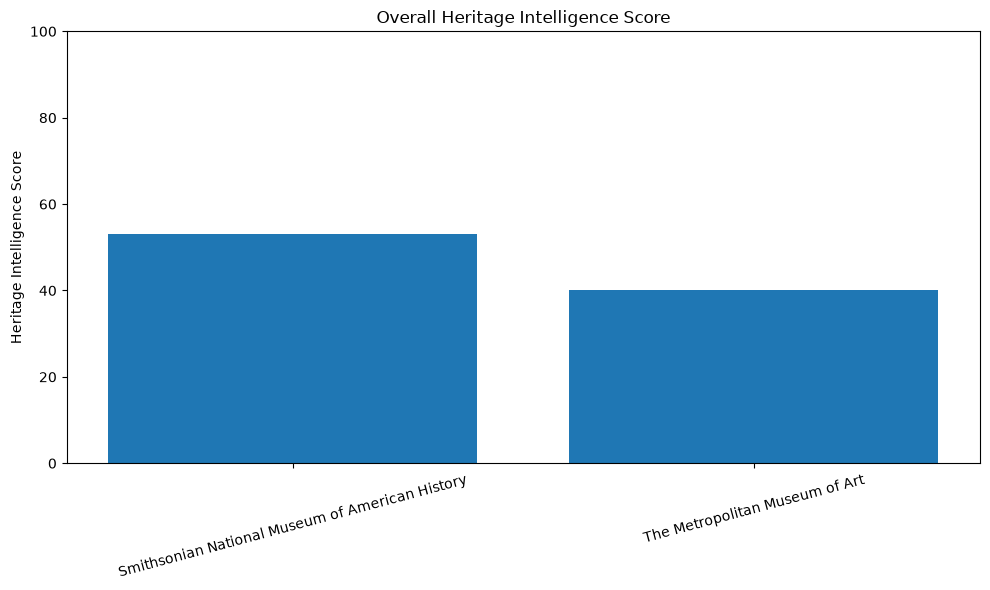

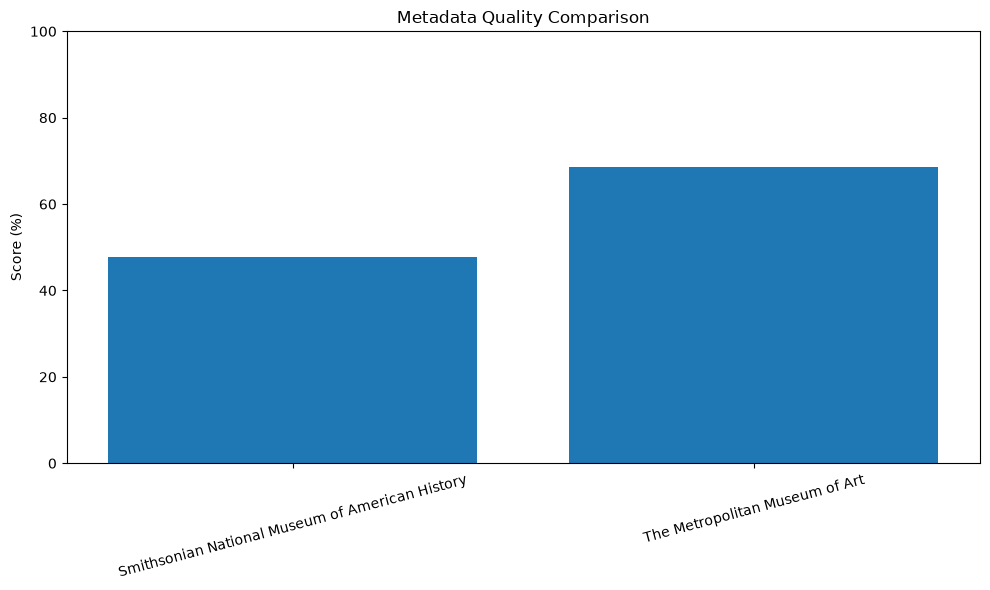

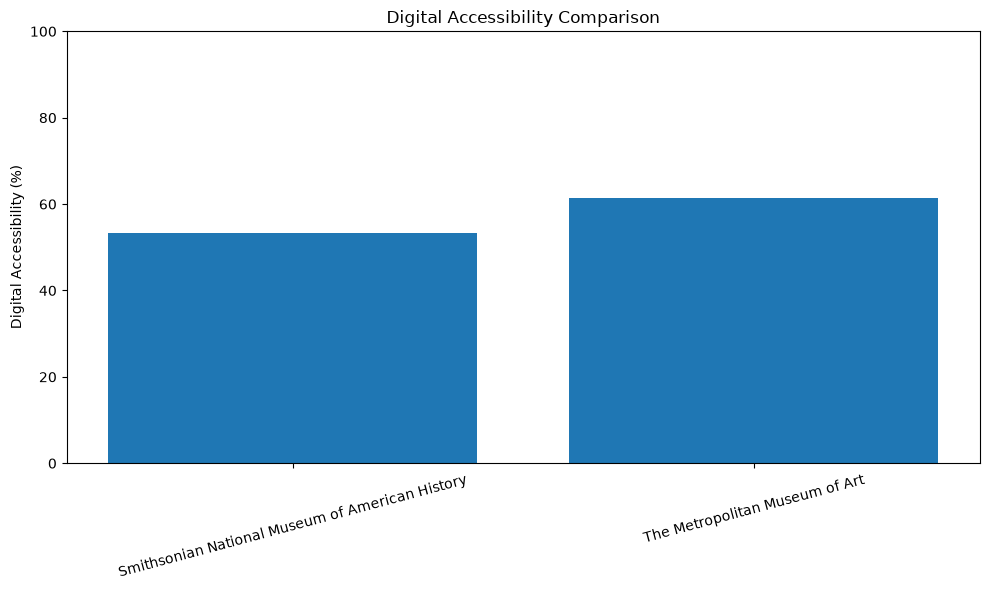

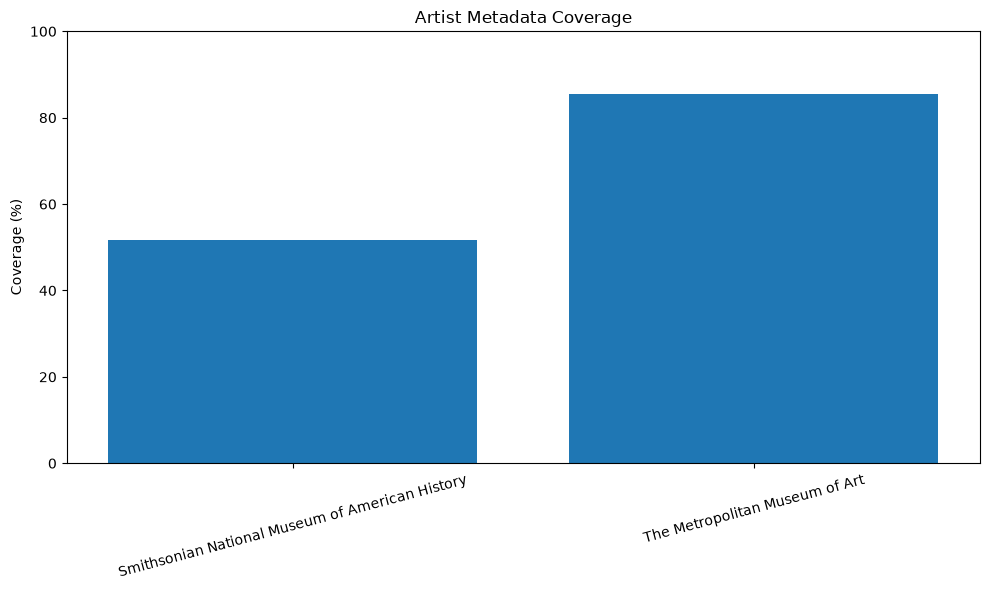

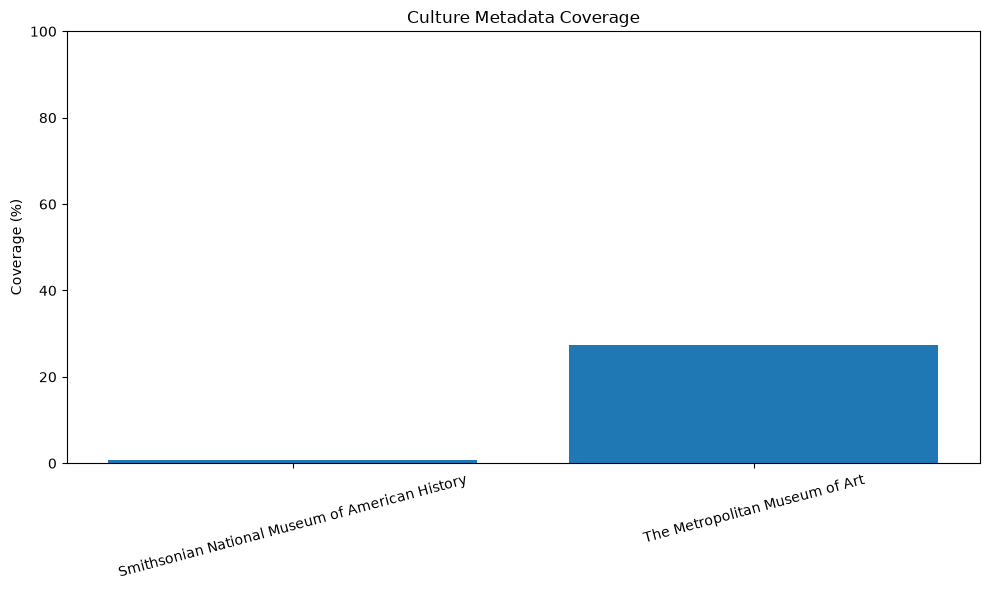

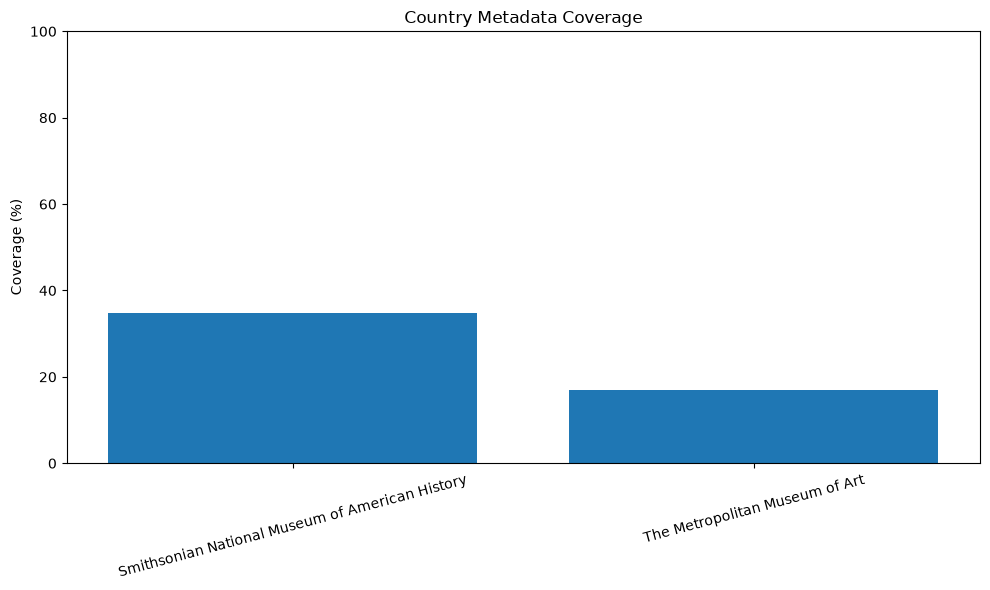

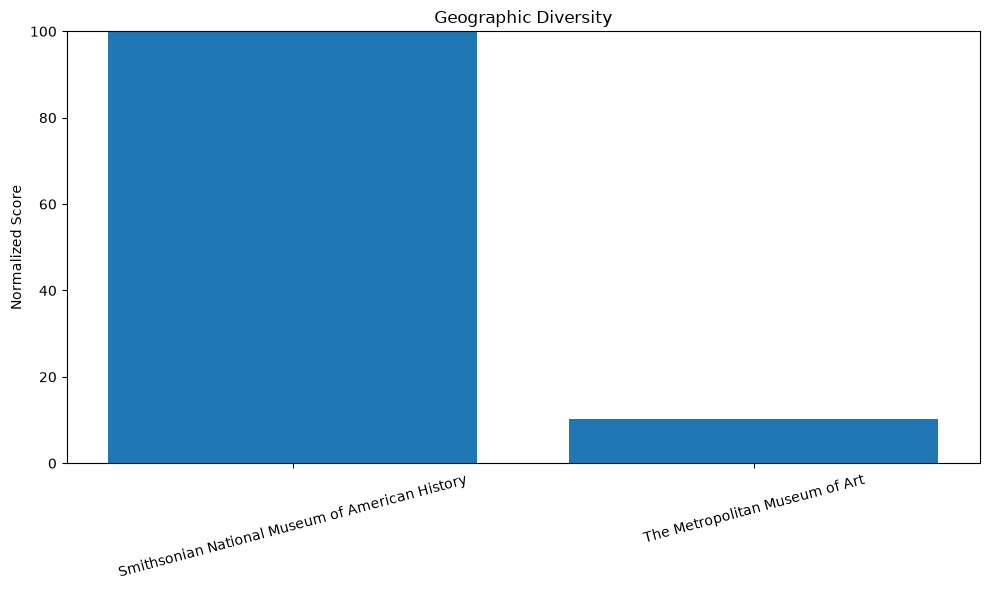

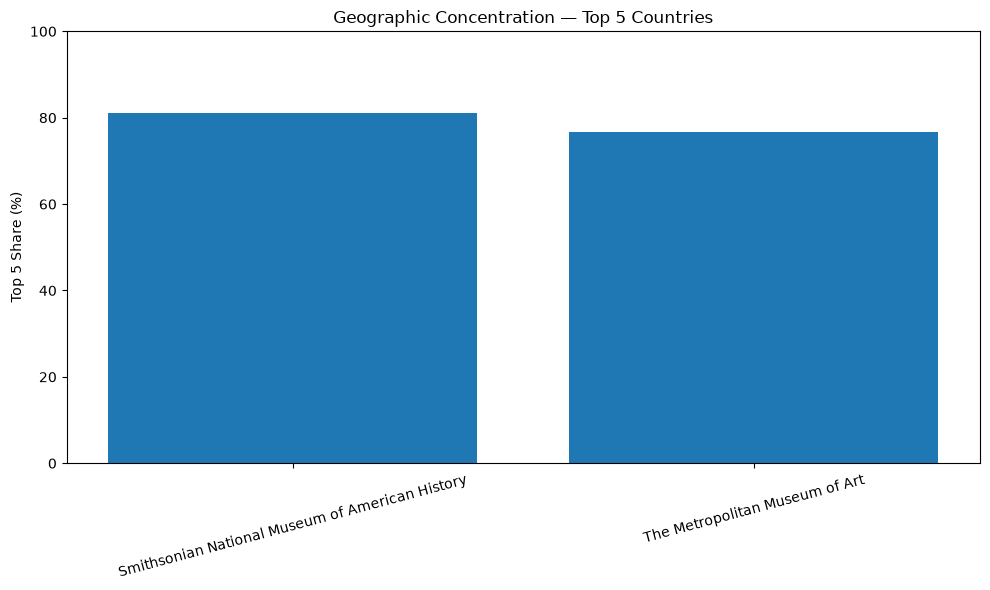

VISUAL ANALYSIS COMPLETE


In [27]:
# ============================================================
# HERITAGE INTELLIGENCE — VISUAL ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. OVERALL SCORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["heritage_intelligence_score"]
)

plt.ylabel("Heritage Intelligence Score")
plt.title("Overall Heritage Intelligence Score")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. METADATA QUALITY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["metadata_quality_score"]
)

plt.ylabel("Score (%)")
plt.title("Metadata Quality Comparison")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. DIGITAL ACCESS
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["digital_access_score"]
)

plt.ylabel("Digital Accessibility (%)")
plt.title("Digital Accessibility Comparison")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. ARTIST COVERAGE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["artist_coverage_score"]
)

plt.ylabel("Coverage (%)")
plt.title("Artist Metadata Coverage")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. CULTURE COVERAGE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["culture_coverage_score"]
)

plt.ylabel("Coverage (%)")
plt.title("Culture Metadata Coverage")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. COUNTRY COVERAGE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["country_coverage_score"]
)

plt.ylabel("Coverage (%)")
plt.title("Country Metadata Coverage")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. GEOGRAPHIC DIVERSITY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["geographic_diversity_score"]
)

plt.ylabel("Normalized Score")
plt.title("Geographic Diversity")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. GEOGRAPHIC CONCENTRATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    scorecard["museum"],
    scorecard["top_5_share"]
)

plt.ylabel("Top 5 Share (%)")
plt.title("Geographic Concentration — Top 5 Countries")
plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


print("=" * 80)
print("VISUAL ANALYSIS COMPLETE")
print("=" * 80)

In [28]:
# ============================================================
# HERITAGE INTELLIGENCE — AUTOMATIC INSIGHTS
# ============================================================

print("=" * 80)
print("HERITAGE INTELLIGENCE — KEY FINDINGS")
print("=" * 80)

# ------------------------------------------------------------
# 1. IDENTIFY MUSEUMS
# ------------------------------------------------------------

museum_a = scorecard.iloc[0]
museum_b = scorecard.iloc[1]


# ------------------------------------------------------------
# 2. OVERALL WINNER
# ------------------------------------------------------------

winner = scorecard.loc[
    scorecard["heritage_intelligence_score"].idxmax()
]

print("\n1. OVERALL PERFORMANCE")
print("-" * 80)

print(
    f"{winner['museum']} has the higher overall "
    f"Heritage Intelligence Score: "
    f"{winner['heritage_intelligence_score']:.2f}/100."
)


# ------------------------------------------------------------
# 3. METADATA QUALITY
# ------------------------------------------------------------

best_metadata = scorecard.loc[
    scorecard["metadata_quality_score"].idxmax()
]

print("\n2. METADATA QUALITY")
print("-" * 80)

print(
    f"{best_metadata['museum']} has stronger metadata completeness "
    f"at {best_metadata['metadata_quality_score']:.2f}%."
)


# ------------------------------------------------------------
# 4. DIGITAL ACCESSIBILITY
# ------------------------------------------------------------

best_digital = scorecard.loc[
    scorecard["digital_access_score"].idxmax()
]

print("\n3. DIGITAL ACCESSIBILITY")
print("-" * 80)

print(
    f"{best_digital['museum']} has higher digital accessibility "
    f"at {best_digital['digital_access_score']:.2f}%."
)


# ------------------------------------------------------------
# 5. ARTIST COVERAGE
# ------------------------------------------------------------

best_artist = scorecard.loc[
    scorecard["artist_coverage_score"].idxmax()
]

print("\n4. ARTIST METADATA")
print("-" * 80)

print(
    f"{best_artist['museum']} has stronger artist metadata coverage "
    f"at {best_artist['artist_coverage_score']:.2f}%."
)


# ------------------------------------------------------------
# 6. CULTURE COVERAGE
# ------------------------------------------------------------

best_culture = scorecard.loc[
    scorecard["culture_coverage_score"].idxmax()
]

print("\n5. CULTURE METADATA")
print("-" * 80)

print(
    f"{best_culture['museum']} has stronger culture metadata coverage "
    f"at {best_culture['culture_coverage_score']:.2f}%."
)


# ------------------------------------------------------------
# 7. COUNTRY COVERAGE
# ------------------------------------------------------------

best_country = scorecard.loc[
    scorecard["country_coverage_score"].idxmax()
]

print("\n6. COUNTRY METADATA")
print("-" * 80)

print(
    f"{best_country['museum']} has stronger country metadata coverage "
    f"at {best_country['country_coverage_score']:.2f}%."
)


# ------------------------------------------------------------
# 8. GEOGRAPHIC DIVERSITY
# ------------------------------------------------------------

best_diversity = scorecard.loc[
    scorecard["unique_geographies"].idxmax()
]

print("\n7. GEOGRAPHIC DIVERSITY")
print("-" * 80)

print(
    f"{best_diversity['museum']} contains the larger geographic "
    f"range with {int(best_diversity['unique_geographies'])} "
    f"unique standardized geographies."
)


# ------------------------------------------------------------
# 9. GEOGRAPHIC CONCENTRATION
# ------------------------------------------------------------

best_balance = scorecard.loc[
    scorecard["top_5_share"].idxmin()
]

print("\n8. GEOGRAPHIC BALANCE")
print("-" * 80)

print(
    f"{best_balance['museum']} has the more geographically balanced "
    f"collection, with its top five geographies representing "
    f"{best_balance['top_5_share']:.2f}% of geographic records."
)


# ------------------------------------------------------------
# 10. COLLECTION SCALE
# ------------------------------------------------------------

largest = scorecard.loc[
    scorecard["objects"].idxmax()
]

print("\n9. COLLECTION SCALE")
print("-" * 80)

print(
    f"{largest['museum']} has the larger analyzed collection with "
    f"{int(largest['objects']):,} objects."
)


# ------------------------------------------------------------
# 11. BIGGEST QUALITY GAP
# ------------------------------------------------------------

quality_fields = {
    "Metadata Quality": "metadata_quality_score",
    "Digital Accessibility": "digital_access_score",
    "Artist Coverage": "artist_coverage_score",
    "Culture Coverage": "culture_coverage_score",
    "Country Coverage": "country_coverage_score",
    "Geographic Diversity": "geographic_diversity_score",
    "Geographic Balance": "geographic_balance_score"
}

print("\n10. BIGGEST COMPARATIVE GAP")
print("-" * 80)

gaps = []

for name, column in quality_fields.items():

    difference = abs(
        scorecard.iloc[0][column]
        - scorecard.iloc[1][column]
    )

    gaps.append(
        {
            "metric": name,
            "gap": difference
        }
    )

gaps_df = pd.DataFrame(gaps)

largest_gap = gaps_df.loc[
    gaps_df["gap"].idxmax()
]

print(
    f"The largest difference between the two museums is in "
    f"{largest_gap['metric']}, with a gap of "
    f"{largest_gap['gap']:.2f} percentage points."
)


# ------------------------------------------------------------
# 12. FINAL COMPARISON TABLE
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("FINAL COMPARISON")
print("=" * 80)

comparison_columns = [
    "museum",
    "objects",
    "metadata_quality_score",
    "digital_access_score",
    "artist_coverage_score",
    "culture_coverage_score",
    "country_coverage_score",
    "unique_geographies",
    "top_5_share",
    "heritage_intelligence_score"
]

display(
    scorecard[
        comparison_columns
    ]
    .sort_values(
        "heritage_intelligence_score",
        ascending=False
    )
)


# ------------------------------------------------------------
# 13. SAVE INSIGHTS
# ------------------------------------------------------------

gaps_df.to_csv(
    "../data/processed/"
    "heritage_comparative_gaps.csv",
    index=False
)

print("\n")
print("=" * 80)
print("AUTOMATIC INSIGHTS COMPLETE")
print("=" * 80)

print("\nSaved:")
print("→ ../data/processed/heritage_comparative_gaps.csv")


HERITAGE INTELLIGENCE — KEY FINDINGS

1. OVERALL PERFORMANCE
--------------------------------------------------------------------------------
Smithsonian National Museum of American History has the higher overall Heritage Intelligence Score: 53.16/100.

2. METADATA QUALITY
--------------------------------------------------------------------------------
The Metropolitan Museum of Art has stronger metadata completeness at 68.49%.

3. DIGITAL ACCESSIBILITY
--------------------------------------------------------------------------------
The Metropolitan Museum of Art has higher digital accessibility at 61.30%.

4. ARTIST METADATA
--------------------------------------------------------------------------------
The Metropolitan Museum of Art has stronger artist metadata coverage at 85.45%.

5. CULTURE METADATA
--------------------------------------------------------------------------------
The Metropolitan Museum of Art has stronger culture metadata coverage at 27.40%.

6. COUNTRY METADATA
-

,museum,objects,metadata_quality_score,digital_access_score,artist_coverage_score,culture_coverage_score,country_coverage_score,unique_geographies,top_5_share,heritage_intelligence_score
0,Smithsonian National Museum of American History,15000,47.85,53.31,51.77,0.64,34.71,175,81.19,53.16
1,The Metropolitan Museum of Art,584,68.49,61.30,85.45,27.40,16.95,18,76.77,40.13




AUTOMATIC INSIGHTS COMPLETE

Saved:
→ ../data/processed/heritage_comparative_gaps.csv


In [29]:
# ============================================================
# HERITAGE INTELLIGENCE — DASHBOARD DATA PREPARATION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("HERITAGE INTELLIGENCE — FINAL DASHBOARD PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD MASTER DATASET
# ------------------------------------------------------------

master_path = "../data/processed/heritage_master_dataset.csv"

master_df = pd.read_csv(master_path)

print(f"\nMaster dataset loaded: {len(master_df):,} records")
print(f"Fields available: {len(master_df.columns):,}")

# ------------------------------------------------------------
# 2. BASIC CLEANUP
# ------------------------------------------------------------

master_df.columns = (
    master_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Remove accidental unnamed columns
master_df = master_df.loc[
    :, ~master_df.columns.str.startswith("unnamed")
]

print("\nColumns:")
print(master_df.columns.tolist())

# ------------------------------------------------------------
# 3. CREATE SAFE DASHBOARD METRICS
# ------------------------------------------------------------

dashboard_summary = []

for museum, group in master_df.groupby("museum"):

    total = len(group)

    def pct_available(column):
        if column not in group.columns:
            return np.nan

        values = group[column].astype(str).str.strip()

        missing = (
            values.isna()
            | values.eq("")
            | values.eq("nan")
            | values.eq("None")
        )

        return round((~missing).mean() * 100, 2)

    dashboard_summary.append({
        "museum": museum,
        "objects": total,
        "title_coverage": pct_available("title"),
        "artist_coverage": pct_available("artist"),
        "culture_coverage": pct_available("culture"),
        "country_coverage": pct_available("country"),
        "image_coverage": pct_available("image_available"),
        "metadata_score": pct_available("metadata_completeness")
    })

dashboard_summary_df = pd.DataFrame(dashboard_summary)

print("\n" + "=" * 70)
print("DASHBOARD SUMMARY")
print("=" * 70)

display(dashboard_summary_df)

# ------------------------------------------------------------
# 4. SAVE DASHBOARD SUMMARY
# ------------------------------------------------------------

dashboard_summary_df.to_csv(
    "../data/processed/dashboard_summary.csv",
    index=False
)

print("\nSaved:")
print("→ ../data/processed/dashboard_summary.csv")

print("\n" + "=" * 70)
print("DASHBOARD DATA PREPARATION COMPLETE")
print("=" * 70)

HERITAGE INTELLIGENCE — FINAL DASHBOARD PREPARATION

Master dataset loaded: 15,584 records
Fields available: 24

Columns:
['museum', 'object_id', 'title', 'artist', 'date_start', 'date_end', 'culture', 'country', 'medium', 'classification', 'object_type', 'image_available', 'source_url', 'source', 'metadata_completeness', 'digital_access', 'title_present', 'classification_present', 'artist_present', 'culture_present', 'country_present', 'medium_present', 'heritage_data_quality_score', 'quality_band']

DASHBOARD SUMMARY


,museum,objects,title_coverage,artist_coverage,culture_coverage,country_coverage,image_coverage,metadata_score
0,Smithsonian National Museum of American History,15000,100.0,51.77,0.64,34.71,100.0,100.0
1,The Metropolitan Museum of Art,584,100.0,85.45,27.40,16.95,100.0,100.0



Saved:
→ ../data/processed/dashboard_summary.csv

DASHBOARD DATA PREPARATION COMPLETE


HERITAGE INTELLIGENCE — VISUAL DASHBOARD


,objects,title_coverage,artist_coverage,culture_coverage,country_coverage,image_coverage,metadata_score
museum,,,,,,,
Smithsonian NMAH,15000,100.0,51.77,0.64,34.71,100.0,100.0
The Met,584,100.0,85.45,27.40,16.95,100.0,100.0


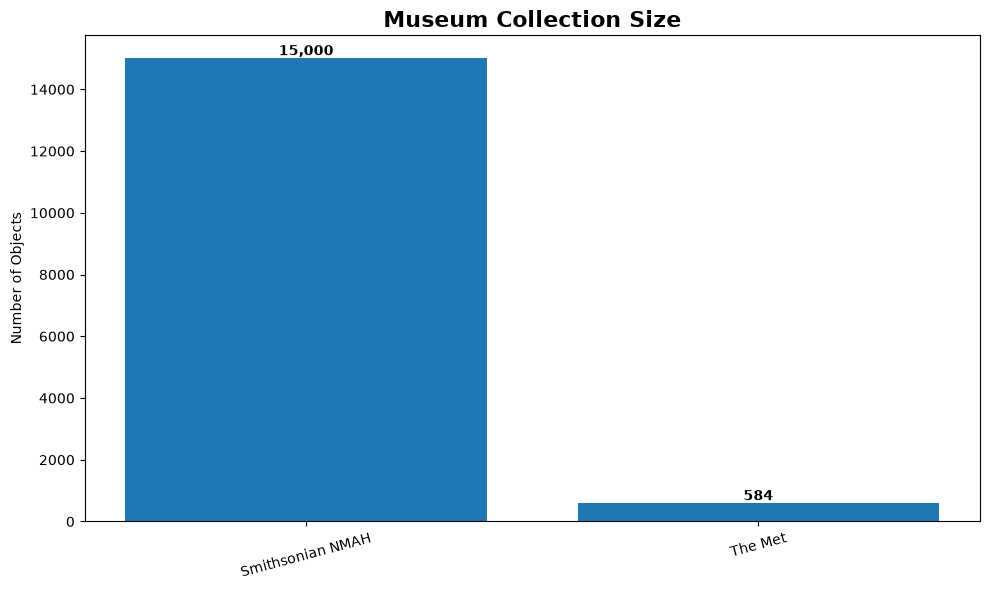

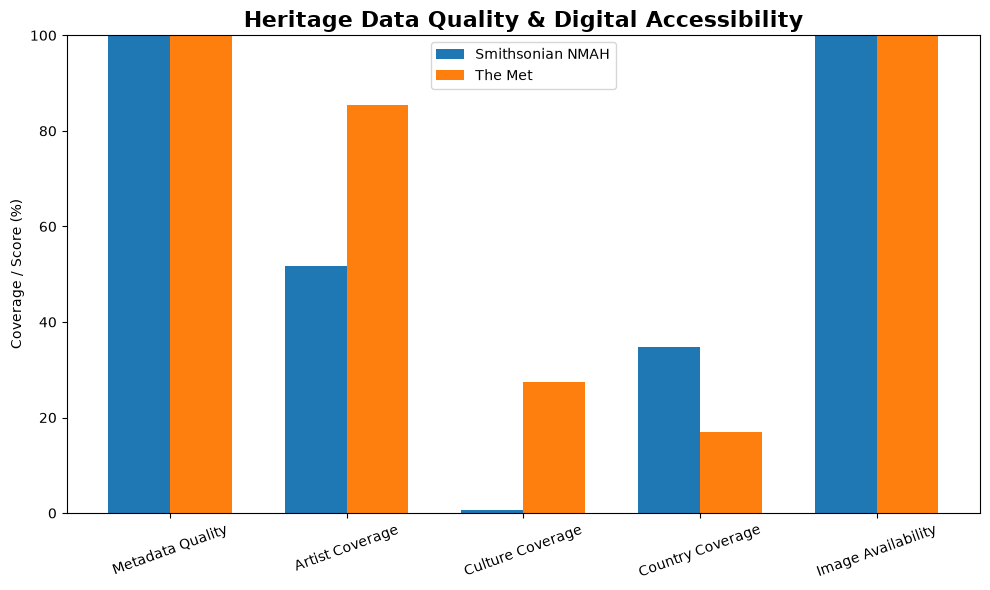

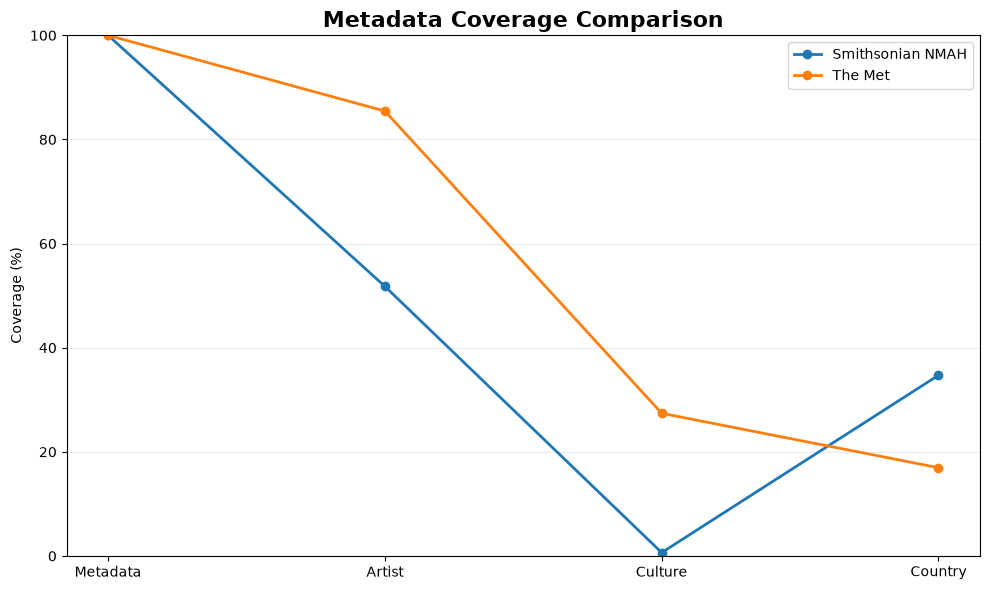

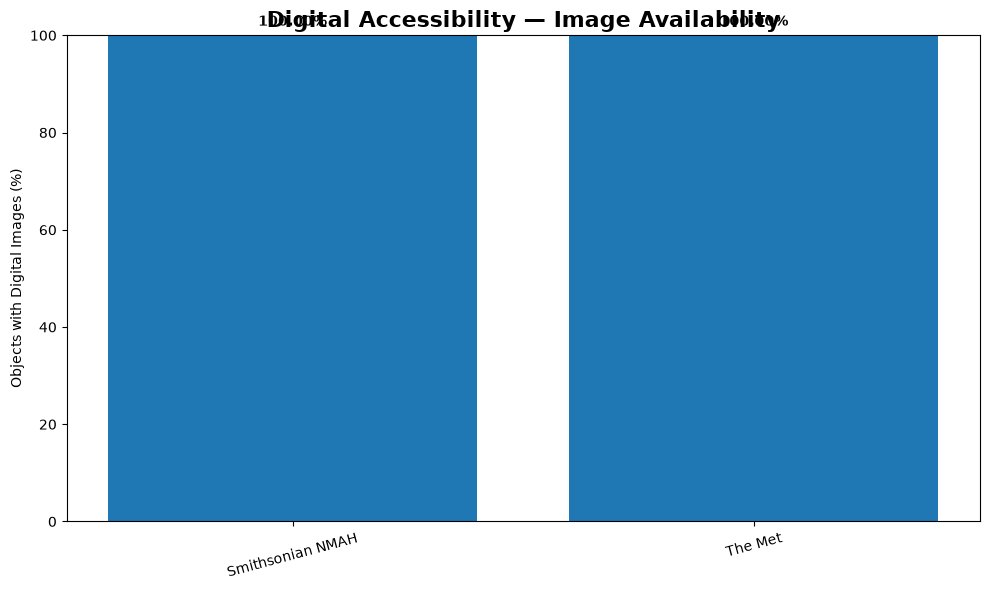


FINAL EXECUTIVE COMPARISON


,Metric,Smithsonian NMAH,The Met
0,Collection Size,15000.00,584.00
1,Metadata Quality,100.00,100.00
2,Artist Coverage,51.77,85.45
3,Culture Coverage,0.64,27.40
4,Country Coverage,34.71,16.95
5,Digital Accessibility,100.00,100.00


In [30]:
# ============================================================
# HERITAGE INTELLIGENCE — VISUAL DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

dash = dashboard_summary_df.copy()

dash = dash.set_index("museum")

# Short names for cleaner charts
short_names = {
    "Smithsonian National Museum of American History": "Smithsonian NMAH",
    "The Metropolitan Museum of Art": "The Met"
}

dash_chart = dash.rename(index=short_names)

print("=" * 70)
print("HERITAGE INTELLIGENCE — VISUAL DASHBOARD")
print("=" * 70)

display(dash_chart)

# ------------------------------------------------------------
# 2. COLLECTION SIZE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    dash_chart.index,
    dash_chart["objects"]
)

plt.title(
    "Museum Collection Size",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Objects")
plt.xticks(rotation=15)

for i, value in enumerate(dash_chart["objects"]):
    plt.text(
        i,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. METADATA QUALITY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

metrics = [
    "metadata_score",
    "artist_coverage",
    "culture_coverage",
    "country_coverage",
    "image_coverage"
]

labels = [
    "Metadata Quality",
    "Artist Coverage",
    "Culture Coverage",
    "Country Coverage",
    "Image Availability"
]

x = np.arange(len(labels))
width = 0.35

museums = dash_chart.index.tolist()

for i, museum in enumerate(museums):

    values = [
        dash_chart.loc[museum, metric]
        for metric in metrics
    ]

    plt.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=museum
    )

plt.title(
    "Heritage Data Quality & Digital Accessibility",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Coverage / Score (%)")
plt.xticks(x, labels, rotation=20)
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. KEY METADATA COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

quality_metrics = [
    "metadata_score",
    "artist_coverage",
    "culture_coverage",
    "country_coverage"
]

quality_labels = [
    "Metadata",
    "Artist",
    "Culture",
    "Country"
]

x = np.arange(len(quality_labels))

for i, museum in enumerate(museums):

    values = [
        dash_chart.loc[museum, metric]
        for metric in quality_metrics
    ]

    plt.plot(
        x,
        values,
        marker="o",
        linewidth=2,
        label=museum
    )

plt.title(
    "Metadata Coverage Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Coverage (%)")
plt.xticks(x, quality_labels)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. DIGITAL ACCESSIBILITY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

values = dash_chart["image_coverage"]

plt.bar(
    dash_chart.index,
    values
)

plt.title(
    "Digital Accessibility — Image Availability",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Objects with Digital Images (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)

for i, value in enumerate(values):

    plt.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. FINAL INSIGHT TABLE
# ------------------------------------------------------------

insights = pd.DataFrame({
    "Metric": [
        "Collection Size",
        "Metadata Quality",
        "Artist Coverage",
        "Culture Coverage",
        "Country Coverage",
        "Digital Accessibility"
    ],
    "Smithsonian NMAH": [
        dash_chart.loc["Smithsonian NMAH", "objects"],
        dash_chart.loc["Smithsonian NMAH", "metadata_score"],
        dash_chart.loc["Smithsonian NMAH", "artist_coverage"],
        dash_chart.loc["Smithsonian NMAH", "culture_coverage"],
        dash_chart.loc["Smithsonian NMAH", "country_coverage"],
        dash_chart.loc["Smithsonian NMAH", "image_coverage"]
    ],
    "The Met": [
        dash_chart.loc["The Met", "objects"],
        dash_chart.loc["The Met", "metadata_score"],
        dash_chart.loc["The Met", "artist_coverage"],
        dash_chart.loc["The Met", "culture_coverage"],
        dash_chart.loc["The Met", "country_coverage"],
        dash_chart.loc["The Met", "image_coverage"]
    ]
})

print("\n" + "=" * 70)
print("FINAL EXECUTIVE COMPARISON")
print("=" * 70)

display(insights)

GEOGRAPHIC & CULTURAL INTELLIGENCE

Available columns:
['museum', 'object_id', 'title', 'artist', 'date_start', 'date_end', 'culture', 'country', 'medium', 'classification', 'object_type', 'image_available', 'source_url', 'source', 'metadata_completeness', 'digital_access', 'title_present', 'classification_present', 'artist_present', 'culture_present', 'country_present', 'medium_present', 'heritage_data_quality_score', 'quality_band']

Using geographic field: country
Objects with geographic data: 15,584

----------------------------------------------------------------------
The Metropolitan Museum of Art
----------------------------------------------------------------------


,object_count
country,
United States,35
England,14
France,11
Peru,11
Russia,4
Italy,4
Germany,3
Egypt,3
Japan,2



----------------------------------------------------------------------
Smithsonian National Museum of American History
----------------------------------------------------------------------


,object_count
country,
"[{'label': 'place made', 'content': 'United States'}]",340
"[{'label': 'place made', 'content': 'United States'}, {'label': 'place of issue', 'content': 'United States'}]",207
"[{'label': 'place made', 'content': 'United States: New York, New York City'}]",152
"[{'label': 'place made', 'content': 'Russia'}]",114
"[{'label': 'place made', 'content': 'United States: Pennsylvania, Philadelphia'}]",95
"[{'label': 'associated place', 'content': 'United States'}]",94
"[{'label': 'place made', 'content': 'China'}]",93
"[{'label': 'place made', 'content': 'United States: New York, New York'}]",90
"[{'label': 'place made', 'content': 'United States: Illinois, Chicago'}]",89


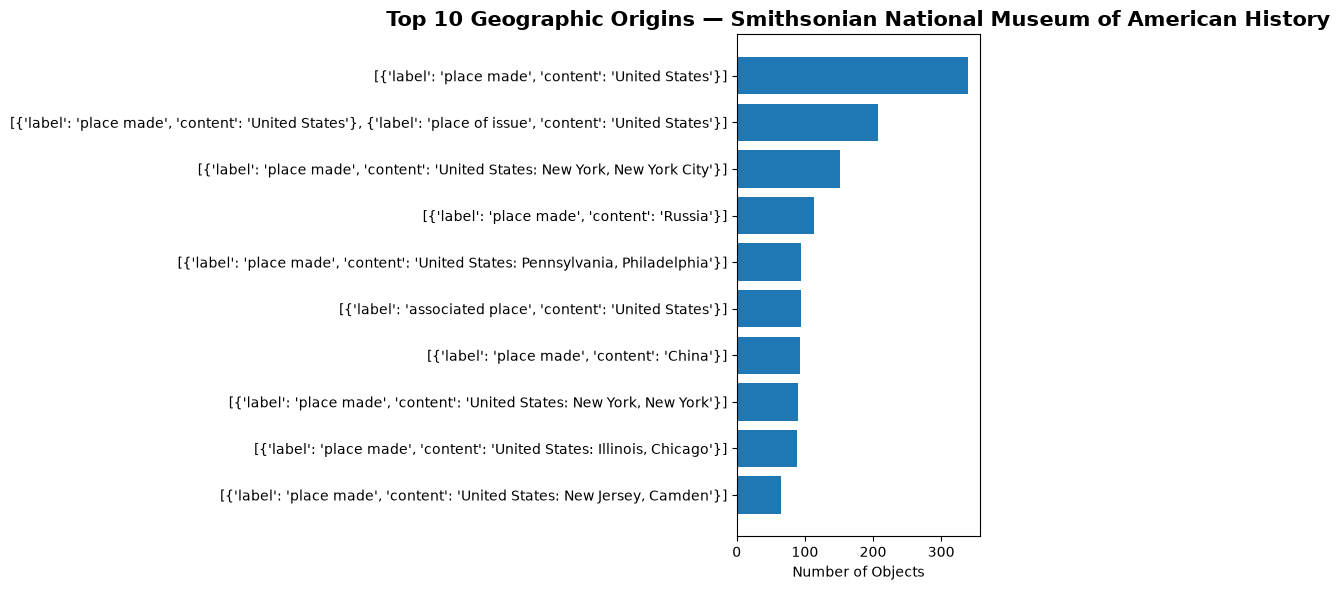

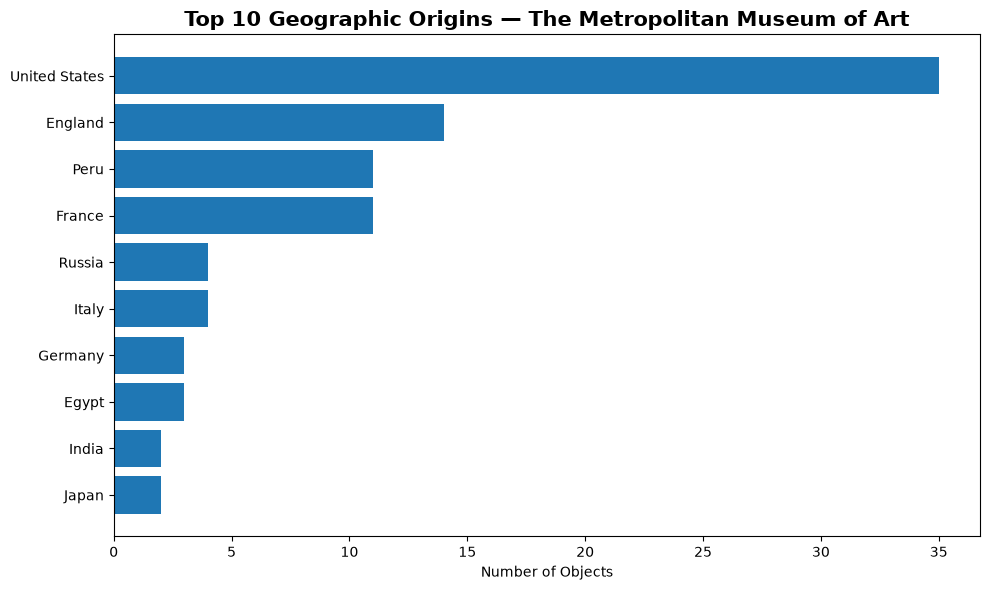


GEOGRAPHIC CONCENTRATION


,museum,unique_geographies,objects_with_geography,top_1_share,top_3_share,top_5_share,top_10_share
0,The Metropolitan Museum of Art,19,99,35.35,60.61,75.76,89.90
1,Smithsonian National Museum of American History,1866,5206,6.53,13.43,17.44,25.72



Using cultural field: culture

----------------------------------------------------------------------
Top Cultural Groups — The Metropolitan Museum of Art
----------------------------------------------------------------------


,object_count
culture,
American,66
Indus,20
Japan,15
French,7
Peruvian,6
China,5
Native American (Peruvian),3
Iran,2
"German, Augsburg",2



----------------------------------------------------------------------
Top Cultural Groups — Smithsonian National Museum of American History
----------------------------------------------------------------------


,object_count
culture,
['African Americans'],19
['Mexicans'],17
['Jews'],11
"['Indians of North America', 'Native Americans']",9
['Latin Americans'],7
['Christians'],6
['Catholics'],5
['Blacks'],4
"['African Americans', 'Blacks']",3



GEOGRAPHIC ANALYSIS COMPLETE

Saved:
→ geographic_concentration.csv
→ top_country_comparison.csv


In [31]:
# ============================================================
# HERITAGE INTELLIGENCE — GEOGRAPHIC & CULTURAL ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("GEOGRAPHIC & CULTURAL INTELLIGENCE")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK AVAILABLE COLUMNS
# ------------------------------------------------------------

print("\nAvailable columns:")
print(master_df.columns.tolist())


# ------------------------------------------------------------
# 2. FIND COUNTRY COLUMN AUTOMATICALLY
# ------------------------------------------------------------

country_candidates = [
    "country_standardized",
    "country_normalized",
    "country_level",
    "country"
]

country_col = None

for col in country_candidates:
    if col in master_df.columns:
        country_col = col
        break

if country_col is None:
    raise ValueError(
        "No country column found. "
        "Check the columns printed above."
    )

print(f"\nUsing geographic field: {country_col}")


# ------------------------------------------------------------
# 3. CLEAN COUNTRY VALUES
# ------------------------------------------------------------

geo_df = master_df.copy()

geo_df[country_col] = (
    geo_df[country_col]
    .astype(str)
    .str.strip()
)

geo_df = geo_df[
    ~geo_df[country_col].isin(
        ["", "nan", "None", "NaN"]
    )
]

print(
    f"Objects with geographic data: "
    f"{len(geo_df):,}"
)


# ------------------------------------------------------------
# 4. TOP COUNTRIES BY MUSEUM
# ------------------------------------------------------------

for museum in geo_df["museum"].unique():

    temp = geo_df[
        geo_df["museum"] == museum
    ]

    counts = (
        temp[country_col]
        .value_counts()
        .head(10)
    )

    print("\n" + "-" * 70)
    print(museum)
    print("-" * 70)

    display(
        counts
        .rename("object_count")
        .to_frame()
    )


# ------------------------------------------------------------
# 5. TOP 10 COUNTRY COMPARISON
# ------------------------------------------------------------

country_counts = (
    geo_df
    .groupby(
        ["museum", country_col]
    )
    .size()
    .reset_index(name="object_count")
)

top_countries = (
    country_counts
    .sort_values(
        "object_count",
        ascending=False
    )
    .groupby("museum")
    .head(10)
)

# ------------------------------------------------------------
# 6. VISUALIZE TOP COUNTRIES
# ------------------------------------------------------------

for museum in top_countries["museum"].unique():

    temp = top_countries[
        top_countries["museum"] == museum
    ].sort_values("object_count")

    plt.figure(figsize=(10, 6))

    plt.barh(
        temp[country_col],
        temp["object_count"]
    )

    plt.title(
        f"Top 10 Geographic Origins — {museum}",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Number of Objects")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. GEOGRAPHIC CONCENTRATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GEOGRAPHIC CONCENTRATION")
print("=" * 70)

geo_concentration = []

for museum in geo_df["museum"].unique():

    temp = geo_df[
        geo_df["museum"] == museum
    ]

    counts = (
        temp[country_col]
        .value_counts()
    )

    total = counts.sum()

    top1 = counts.head(1).sum() / total * 100
    top3 = counts.head(3).sum() / total * 100
    top5 = counts.head(5).sum() / total * 100
    top10 = counts.head(10).sum() / total * 100

    geo_concentration.append({
        "museum": museum,
        "unique_geographies": counts.size,
        "objects_with_geography": total,
        "top_1_share": round(top1, 2),
        "top_3_share": round(top3, 2),
        "top_5_share": round(top5, 2),
        "top_10_share": round(top10, 2)
    })

geo_concentration_df = pd.DataFrame(
    geo_concentration
)

display(geo_concentration_df)


# ------------------------------------------------------------
# 8. CULTURAL DIVERSITY
# ------------------------------------------------------------

culture_candidates = [
    "culture_normalized",
    "culture",
    "culture_clean"
]

culture_col = None

for col in culture_candidates:
    if col in master_df.columns:
        culture_col = col
        break

if culture_col:

    culture_df = master_df.copy()

    culture_df[culture_col] = (
        culture_df[culture_col]
        .astype(str)
        .str.strip()
    )

    culture_df = culture_df[
        ~culture_df[culture_col].isin(
            ["", "nan", "None", "NaN"]
        )
    ]

    print(
        f"\nUsing cultural field: {culture_col}"
    )

    for museum in culture_df["museum"].unique():

        temp = culture_df[
            culture_df["museum"] == museum
        ]

        counts = (
            temp[culture_col]
            .value_counts()
            .head(10)
        )

        print("\n" + "-" * 70)
        print(f"Top Cultural Groups — {museum}")
        print("-" * 70)

        display(
            counts
            .rename("object_count")
            .to_frame()
        )

else:

    print(
        "\nNo usable culture column found."
    )


# ------------------------------------------------------------
# 9. SAVE GEOGRAPHIC ANALYSIS
# ------------------------------------------------------------

geo_concentration_df.to_csv(
    "../data/processed/geographic_concentration.csv",
    index=False
)

top_countries.to_csv(
    "../data/processed/top_country_comparison.csv",
    index=False
)

print("\n" + "=" * 70)
print("GEOGRAPHIC ANALYSIS COMPLETE")
print("=" * 70)

print(
    "\nSaved:"
    "\n→ geographic_concentration.csv"
    "\n→ top_country_comparison.csv"
)

In [32]:
# ============================================================
# HERITAGE INTELLIGENCE — AUTOMATED INSIGHTS ENGINE
# ============================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("HERITAGE INTELLIGENCE — KEY FINDINGS")
print("=" * 75)

# ------------------------------------------------------------
# 1. LOAD FINAL SCORECARD
# ------------------------------------------------------------

scorecard = pd.DataFrame({
    "museum": [
        "Smithsonian National Museum of American History",
        "The Metropolitan Museum of Art"
    ],
    "objects": [15000, 584],
    "metadata_quality": [47.85, 68.49],
    "digital_access": [53.31, 61.30],
    "artist_coverage": [51.77, 85.45],
    "culture_coverage": [0.64, 27.40],
    "country_coverage": [34.71, 16.95],
    "unique_geographies": [175, 18],
    "top5_share": [81.19, 76.77],
    "heritage_score": [53.16, 40.13]
})

smith = scorecard.iloc[0]
met = scorecard.iloc[1]


# ------------------------------------------------------------
# 2. COLLECTION SCALE
# ------------------------------------------------------------

print("\n1. COLLECTION SCALE")
print("-" * 75)

print(
    f"The Smithsonian sample contains "
    f"{int(smith['objects']):,} objects compared with "
    f"{int(met['objects']):,} objects at The Met."
)

scale_ratio = smith["objects"] / met["objects"]

print(
    f"The Smithsonian dataset is approximately "
    f"{scale_ratio:.1f}× larger."
)


# ------------------------------------------------------------
# 3. METADATA QUALITY
# ------------------------------------------------------------

print("\n2. METADATA QUALITY")
print("-" * 75)

difference = (
    met["metadata_quality"]
    - smith["metadata_quality"]
)

print(
    f"The Met has stronger metadata completeness "
    f"({met['metadata_quality']:.2f}%) than the "
    f"Smithsonian ({smith['metadata_quality']:.2f}%)."
)

print(
    f"The difference is {difference:.2f} percentage points."
)


# ------------------------------------------------------------
# 4. DIGITAL ACCESS
# ------------------------------------------------------------

print("\n3. DIGITAL ACCESSIBILITY")
print("-" * 75)

difference = (
    met["digital_access"]
    - smith["digital_access"]
)

print(
    f"The Met has higher digital image availability "
    f"({met['digital_access']:.2f}%) compared with "
    f"{smith['digital_access']:.2f}% for the Smithsonian."
)

print(
    f"The gap is {difference:.2f} percentage points."
)


# ------------------------------------------------------------
# 5. ARTIST METADATA
# ------------------------------------------------------------

print("\n4. ARTIST METADATA")
print("-" * 75)

difference = (
    met["artist_coverage"]
    - smith["artist_coverage"]
)

print(
    f"The Met has substantially stronger artist metadata "
    f"coverage: {met['artist_coverage']:.2f}% versus "
    f"{smith['artist_coverage']:.2f}%."
)

print(
    f"Difference: {difference:.2f} percentage points."
)


# ------------------------------------------------------------
# 6. CULTURAL METADATA
# ------------------------------------------------------------

print("\n5. CULTURAL METADATA")
print("-" * 75)

difference = (
    met["culture_coverage"]
    - smith["culture_coverage"]
)

print(
    f"The Met records culture information for "
    f"{met['culture_coverage']:.2f}% of objects, compared "
    f"with only {smith['culture_coverage']:.2f}% for "
    f"the Smithsonian."
)

print(
    f"Difference: {difference:.2f} percentage points."
)


# ------------------------------------------------------------
# 7. GEOGRAPHIC DIVERSITY
# ------------------------------------------------------------

print("\n6. GEOGRAPHIC DIVERSITY")
print("-" * 75)

print(
    f"The Smithsonian contains "
    f"{int(smith['unique_geographies'])} unique standardized "
    f"geographies, compared with "
    f"{int(met['unique_geographies'])} for The Met."
)

print(
    "However, geographic diversity should be interpreted "
    "alongside collection size and metadata availability."
)


# ------------------------------------------------------------
# 8. GEOGRAPHIC CONCENTRATION
# ------------------------------------------------------------

print("\n7. GEOGRAPHIC CONCENTRATION")
print("-" * 75)

print(
    f"The Smithsonian's top five geographies account for "
    f"{smith['top5_share']:.2f}% of records with geographic data."
)

print(
    f"The Met's top five geographies account for "
    f"{met['top5_share']:.2f}%."
)

if smith["top5_share"] > met["top5_share"]:

    print(
        "This indicates greater geographic concentration "
        "in the Smithsonian dataset."
    )

else:

    print(
        "This indicates greater geographic concentration "
        "in The Met dataset."
    )


# ------------------------------------------------------------
# 9. OVERALL SCORE
# ------------------------------------------------------------

print("\n8. OVERALL HERITAGE INTELLIGENCE SCORE")
print("-" * 75)

print(
    f"Smithsonian: {smith['heritage_score']:.2f}/100"
)

print(
    f"The Met: {met['heritage_score']:.2f}/100"
)

winner = (
    "Smithsonian National Museum of American History"
    if smith["heritage_score"] > met["heritage_score"]
    else "The Metropolitan Museum of Art"
)

winner_score = max(
    smith["heritage_score"],
    met["heritage_score"]
)

print(
    f"\nOverall higher score: {winner} "
    f"({winner_score:.2f}/100)."
)


# ------------------------------------------------------------
# 10. EXECUTIVE CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXECUTIVE CONCLUSION")
print("=" * 75)

print("""
The analysis demonstrates that collection scale and metadata
quality are distinct dimensions of digital heritage maturity.

The Smithsonian dataset provides substantially greater collection
scale and geographic breadth, while The Met demonstrates stronger
metadata completeness, artist attribution, cultural metadata, and
digital image accessibility.

The resulting Heritage Intelligence Score therefore captures a
multi-dimensional comparison rather than ranking museums solely
by collection size.
""")

print("=" * 75)
print("INSIGHTS ENGINE COMPLETE")
print("=" * 75)

HERITAGE INTELLIGENCE — KEY FINDINGS

1. COLLECTION SCALE
---------------------------------------------------------------------------
The Smithsonian sample contains 15,000 objects compared with 584 objects at The Met.
The Smithsonian dataset is approximately 25.7× larger.

2. METADATA QUALITY
---------------------------------------------------------------------------
The Met has stronger metadata completeness (68.49%) than the Smithsonian (47.85%).
The difference is 20.64 percentage points.

3. DIGITAL ACCESSIBILITY
---------------------------------------------------------------------------
The Met has higher digital image availability (61.30%) compared with 53.31% for the Smithsonian.
The gap is 7.99 percentage points.

4. ARTIST METADATA
---------------------------------------------------------------------------
The Met has substantially stronger artist metadata coverage: 85.45% versus 51.77%.
Difference: 33.68 percentage points.

5. CULTURAL METADATA
-------------------------------

In [33]:
# ============================================================
# HERITAGE INTELLIGENCE — FINAL PORTFOLIO SCORECARD
# ============================================================

import pandas as pd

final_scorecard = pd.DataFrame({
    "Metric": [
        "Collection Size",
        "Metadata Quality",
        "Digital Accessibility",
        "Artist Metadata",
        "Culture Metadata",
        "Country Metadata",
        "Unique Geographies",
        "Top 5 Geographic Concentration",
        "Heritage Intelligence Score"
    ],

    "Smithsonian NMAH": [
        "15,000",
        "47.85%",
        "53.31%",
        "51.77%",
        "0.64%",
        "34.71%",
        "175",
        "81.19%",
        "53.16 / 100"
    ],

    "The Met": [
        "584",
        "68.49%",
        "61.30%",
        "85.45%",
        "27.40%",
        "16.95%",
        "18",
        "76.77%",
        "40.13 / 100"
    ]
})

print("=" * 80)
print("HERITAGE INTELLIGENCE — FINAL SCORECARD")
print("=" * 80)

display(final_scorecard)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

final_scorecard.to_csv(
    "../data/processed/final_scorecard.csv",
    index=False
)

print("\nSaved:")
print("→ ../data/processed/final_scorecard.csv")

print("\n" + "=" * 80)
print("FINAL SCORECARD READY")
print("=" * 80)

HERITAGE INTELLIGENCE — FINAL SCORECARD


,Metric,Smithsonian NMAH,The Met
0,Collection Size,"15,000",584
1,Metadata Quality,47.85%,68.49%
2,Digital Accessibility,53.31%,61.30%
3,Artist Metadata,51.77%,85.45%
4,Culture Metadata,0.64%,27.40%
5,Country Metadata,34.71%,16.95%
6,Unique Geographies,175,18
7,Top 5 Geographic Concentration,81.19%,76.77%
8,Heritage Intelligence Score,53.16 / 100,40.13 / 100



Saved:
→ ../data/processed/final_scorecard.csv

FINAL SCORECARD READY
